Importing the Necessary Modules

In [1]:
import pandas as pd
from sqlalchemy import create_engine
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import pyplot
import random
import json
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Connecting to the Database

In [2]:
db_username_0 = 'simulationuser'
db_password_0 = 'simulations2024'
db_host_0 = 'localhost'
db_port_0 = '5432'
db_name_0 = 'simulations_data'
table_name_0 = 'composite_data'

db_username_1 = 'simulationuser'
db_password_1 = 'simulations2024'
db_host_1 = 'localhost'
db_port_1 = '5432'
db_name_1 = 'simulations_data'
table_name_1 = 'neutral_ensembles_laterpart'

In [3]:
# DB 0
connection_string_0 = f"postgresql://{db_username_0}:{db_password_0}@{db_host_0}:{db_port_0}/{db_name_0}"
engine_0 = create_engine(connection_string_0)

query_0 = f"SELECT * FROM {table_name_0} LIMIT 7000"
df = pd.read_sql(query_0, engine_0)


In [4]:


# DB 1
connection_string_1 = f"postgresql://{db_username_1}:{db_password_1}@{db_host_1}:{db_port_1}/{db_name_1}"
engine_1 = create_engine(connection_string_1)

query_1 = f"SELECT * FROM {table_name_1} LIMIT 7000"
df1 = pd.read_sql(query_1, engine_1)


The DataFrame

In [5]:
df.head()

,id,eps,n_0_squared,psi_e,b_e,psi_plus,b_plus,u_list,r_list,k_e_psi_e_list,k_e_b_e_list,k_e_psi_plus_list,k_e_b_plus_list,heat_flux_psi_e_b_e_list,heat_flux_psi_e_b_plus_list,b_e_psi_plus_list,b_e_b_plus_list,psi_plus_b_plus_list,eta_list
0,1500,0.123943,318.864022,"[-0.011744609035812982, -0.011215305626181015,...","[-5.517162102724528, -3.1920707854231463, -0.9...","[-0.0016475367466768115, -0.002355776502265530...","[10.73076649947905, 10.77581128940965, 10.5402...","[0.4615413218450946, 0.4686702377764153, 0.478...","[0.6551578220909112, 0.8945764375320215, 1.175...","[0.00013793584140409996, 0.0001257830802886475...","[30.43907766773974, 10.189315899151941, 0.8663...","[2.7143773316504123e-06, 5.549682928626416e-06...","[115.14934966634185, 116.11810894496844, 111.0...","[0.06479691188370344, 0.035800049438924265, 0....","[-0.1260286571909809, -0.12085401698078094, -0...","[0.009089727301611367, 0.007519805349868124, 0...","[-59.203378264111755, -34.39715240615747, -9.8...","[-0.01767933212790023, -0.025385403028438877, ...","[[1.0369206541904592], [-1.6813054180526377], ..."
1,1501,0.123943,318.864022,"[-0.008147157474100065, -0.008292099833020762,...","[-0.832904729882089, 0.14071461474575664, 1.27...","[0.0006807256129005129, 0.0007313699095774325,...","[-0.7190970906032216, -0.6095182673572732, -0....","[0.23703131704960073, 0.23479400902756253, 0.2...","[-0.18778048603775238, -0.2053401462453807, -0...","[6.637617490778455e-05, 6.875891964078295e-05,...","[0.6937302890599556, 0.019800602803046713, 1.6...","[4.6338736005877887e-07, 5.349019446353018e-07...","[0.5171006257140178, 0.3715125182422124, 0.293...","[0.006785805995272157, -0.0011668196334368695,...","[0.005858597236311648, 0.005054186322976349, 0...","[-0.0005669795827367211, 0.0001029144350628272...","[0.5989393680078723, -0.0857681281716798, -0.6...","[-0.0004895078077358536, -0.000445783320082882...","[[1.418213787060706], [0.8827834628841255], [0..."
2,1502,0.123943,318.864022,"[-0.003781434990007615, -0.001308768972368787,...","[7.429632504232679, 7.616174400779771, 7.45893...","[0.0017201097552821953, 0.0016973192181066884,...","[0.26192796713213556, -0.016191321040263613, -...","[0.3398928494975913, 0.33847860008307173, 0.33...","[-0.22023434840890527, -0.0752140155360062, 0....","[1.4299250583653892e-05, 1.7128762230352505e-0...","[55.199439147950756, 58.00611250309311, 55.635...","[2.958777570216974e-06, 2.8808925281543e-06, 2...","[0.06860625996597308, 0.0002621588770288832, 0...","[-0.028094672314403355, -0.009967812743890003,...","[-0.000990463579775022, 2.1190698599158928e-05...","[0.012779783348692317, 0.012927079178895698, 0...","[1.9460285383725033, -0.12331592482166262, -2....","[0.00045054485144522063, -2.7481840368174608e-...","[[-0.6679438799496836], [-0.8041216677662598],..."
3,1503,0.123943,318.864022,"[-0.008102021680746106, -0.007577287179778589,...","[-13.405475487140006, -12.142974722866745, -10...","[-0.007065355563569785, -0.007211423776971252,...","[3.432058579711073, 2.9279736455346024, 2.4210...","[0.15021463519080008, 0.17082991418834997, 0.1...","[1.9382048681079675, 1.850150346137473, 2.4148...","[6.564275531527996e-05, 5.7415281004836965e-05...","[179.70677303631157, 147.4518351201807, 119.05...","[4.991924923966652e-05, 5.2004632891066315e-05...","[11.779026094568387, 8.573029668945189, 5.8616...","[0.10861145303751879, 0.09201080669195365, 0.1...","[-0.0278066130224098, -0.022186097167038923, -...","[0.09471445081536302, 0.08756813663964214, 0.0...","[-46.00837716074533, -35.55430996694667, -26.4...","[-0.024248714180659044, -0.021114858765753426,...","[[0.20668630436664126], [1.0343110874926529], ..."
4,1504,0.123943,318.864022,"[-0.0007052290130828054, -0.003475921446700475...","[7.188510348955567, 7.255315274332748, 7.40112...","[0.01155266108186768, 0.011468163968599393, 0....","[-0.9665805895951766, 0.23618988496103174, 1.4...","[0.1388431307750241, 0.13278906064134477, 0.12...","[-0.2758572865676108, -1.349696442983

In [6]:
df1.head()

,id,eps,n_0_squared,psi_e,b_e,psi_plus,b_plus,u_list,r_list,k_e_psi_e_list,k_e_b_e_list,k_e_psi_plus_list,k_e_b_plus_list,heat_flux_psi_e_b_e_list,heat_flux_psi_e_b_plus_list,b_e_psi_plus_list,b_e_b_plus_list,psi_plus_b_plus_list,eta_list
0,10806,0.123943,318.864022,"[-0.005263116110195544, -0.004833993533306217,...","[-5.738685945040112, -5.0705091259454385, -4.3...","[0.0011330888601536937, 0.001130892184774879, ...","[-0.21346875822905956, 0.24160998068202566, 0....","[0.3123144940995926, 0.31005662655526317, 0.30...","[-0.20191992555234548, -0.18509706157315295, -...","[2.770039118939987e-05, 2.336749348004632e-05,...","[32.93251637580092, 25.710062796295976, 19.265...","[1.2838903650043967e-06, 1.2789171335848993e-0...","[0.04556891073985668, 0.058375382765168814, 0....","[0.030203370448693354, 0.024510808325390408, 0...","[0.0011235108604588009, -0.001167941084199152,...","[-0.006502441116245523, -0.0057341991433614, -...","[1.2250301625542699, -1.2250856119677123, -2.8...","[-0.0002418790719401895, 0.0002732348389169123...","[[-0.5307351375825039], [-0.72113039666269], [..."
1,10807,0.123943,318.864022,"[-0.0094030807577941, -0.00974045838040496, -0...","[-10.308013819139813, -9.10929784915359, -7.73...","[0.00251303801692815, 0.002578908660653808, 0....","[-1.4756298510075572, -0.3916484974200489, 0.5...","[0.42110583049483324, 0.41218065273667226, 0.4...","[-0.8000948612452045, -0.8505260349881524, -0....","[8.841792773759766e-05, 9.487652946040121e-05,...","[106.25514889557735, 82.97930730459422, 59.861...","[6.315360074526168e-06, 6.6507698799952184e-06...","[2.1774834571845854, 0.15338854553138206, 0.32...","[0.09692708639382924, 0.08872873657439295, 0.0...","[0.013875466657635735, 0.0038148358888681257, ...","[-0.02590443060651908, -0.023492047115657298, ...","[15.210812896121123, 3.567642815172687, -4.416...","[-0.0037083139144960127, -0.001010025701928614...","[[-2.2678357294709035], [-0.27601393159263354]..."
2,10808,0.123943,318.864022,"[0.0026365271906255063, -0.0003296947868911644...","[0.8641990879984902, 1.2776601107365166, 1.803...","[-0.0010738126456424008, -0.001514200368660820...","[6.552484747849733, 6.2518738844902915, 5.8632...","[0.4353125621579292, 0.434668648295842, 0.4344...","[-0.09585902891415952, 0.01690315150828116, 0....","[6.951275626907625e-06, 1.0869865250321033e-07...","[0.7468400636974222, 1.632415358567248, 3.2516...","[1.1530735979415322e-06, 2.292802756452564e-06...","[42.93505637080338, 39.085927067571724, 34.378...","[0.002278484393621784, -0.0004212378779286174,...","[0.017275804203864736, -0.002061210228017463, ...","[-0.0009279879090454087, -0.001934633410700457...","[5.662651343215757, 7.987769879568602, 10.5729...","[-0.007036140982620002, -0.009466589740716154,...","[[0.5076519604567276], [-0.4841603270322568], ..."
3,10809,0.123943,318.864022,"[0.0027554815493586182, 0.0025887276908364274,...","[-2.1075102746393055, -2.6015535257139, -3.278...","[-0.004306100540115291, -0.003996904511036068,...","[-3.704494536833324, -4.05177630178608, -4.334...","[0.2635301488081057, 0.2594758292572965, 0.253...","[-0.40174819058302996, -0.3503340893191492, -0...","[7.592678568855771e-06, 6.701511057303302e-06,...","[4.441599557710241, 6.768080747154424, 10.7498...","[1.8542501861581202e-05, 1.5975245670340474e-0...","[13.723279773427944, 16.416891199715284, 18.78...","[-0.005807205676852321, -0.006734713651208711,...","[-0.010207666345944024, -0.010488945509508438,...","[0.009075151131922839, 0.010398161022627675, 0...","[7.807260298721405, 10.540912923315602, 14.212...","[0.015951925925912123, 0.016194562978317822, 0...","[[0.07446519703019526], [-0.15551658747134606]..."
4,10810,0.123943,318.864022,"[-0.005466525552320282, -0.008556111032236668,...","[5.8845177041630645, 6.472608872078704, 6.8874...","[0.0007224042477245032, 0.0010587667385948852,...","[-4.696354009298316, -4.843722789141135, -4.97...","[0.26107688174283095, 0.25844495057669725, 0.2...","[-0.13371001264815321, -0.306724

Verifying Details

Defining Common Functions

In [7]:
def average_arrays(*arrays):
    if not arrays:
        raise ValueError("No arrays provided for averaging.")
    
    np_arrays = [np.array(arr) for arr in arrays]
    array_lengths = [len(arr) for arr in np_arrays]

    if len(set(array_lengths)) != 1:
        raise ValueError("All input arrays must have the same length.")
    
    average_array = np.mean(np_arrays, axis=0)
    
    return average_array

In [8]:
def average_eta_arrays(*arrays):
    if not arrays:
        raise ValueError("No arrays provided for averaging.")
    
    np_arrays = [np.array(arr) for arr in arrays]
    array_lengths = [len(arr) for arr in np_arrays]

    if len(set(array_lengths)) != 1:
        raise ValueError("All input arrays must have the same length.")
    
    average_array = np.mean(np.abs(np_arrays), axis=0)
    
    return average_array

Composite Analysis of All the Data

In [9]:
average_psi_e = average_arrays(*list(df['psi_e']))
average_b_e = average_arrays(*list(df['b_e']))
average_psi_plus = average_arrays(*list(df['psi_plus']))
average_b_plus = average_arrays(*list(df['b_plus']))
average_U = average_arrays(*list(df['u_list']))
average_R = average_arrays(*list(df['r_list']))
average_k_e_psi_e_list = average_arrays(*list(df['k_e_psi_e_list']))
average_k_e_b_e_list = average_arrays(*list(df['k_e_b_e_list']))
average_k_e_psi_plus_list = average_arrays(*list(df['k_e_psi_plus_list']))
average_k_e_b_plus_list = average_arrays(*list(df['k_e_b_plus_list']))
average_heat_flux_psi_e_b_e_list = average_arrays(*list(df['heat_flux_psi_e_b_e_list']))
average_heat_flux_psi_e_b_plus_list = average_arrays(*list(df['heat_flux_psi_e_b_plus_list']))
average_b_e_psi_plus_list = average_arrays(*list(df['b_e_psi_plus_list']))
average_b_e_b_plus_list = average_arrays(*list(df['b_e_b_plus_list']))
average_psi_plus_b_plus_list = average_arrays(*list(df['psi_plus_b_plus_list']))
average_eta = average_arrays(*list(df['eta_list']))

average_psi_e_1 = average_arrays(*list(df1['psi_e']))
average_b_e_1 = average_arrays(*list(df1['b_e']))
average_psi_plus_1 = average_arrays(*list(df1['psi_plus']))
average_b_plus_1 = average_arrays(*list(df1['b_plus']))
average_U_1 = average_arrays(*list(df1['u_list']))
average_R_1 = average_arrays(*list(df1['r_list']))
average_k_e_psi_e_list_1 = average_arrays(*list(df1['k_e_psi_e_list']))
average_k_e_b_e_list_1 = average_arrays(*list(df1['k_e_b_e_list']))
average_k_e_psi_plus_list_1 = average_arrays(*list(df1['k_e_psi_plus_list']))
average_k_e_b_plus_list_1 = average_arrays(*list(df1['k_e_b_plus_list']))
average_heat_flux_psi_e_b_e_list_1 = average_arrays(*list(df1['heat_flux_psi_e_b_e_list']))
average_heat_flux_psi_e_b_plus_list_1 = average_arrays(*list(df1['heat_flux_psi_e_b_plus_list']))
average_b_e_psi_plus_list_1 = average_arrays(*list(df1['b_e_psi_plus_list']))
average_b_e_b_plus_list_1 = average_arrays(*list(df1['b_e_b_plus_list']))
average_psi_plus_b_plus_list_1 = average_arrays(*list(df1['psi_plus_b_plus_list']))
average_eta_1 = average_arrays(*list(df1['eta_list']))


In [10]:
average_eta = average_eta_arrays(*list(df['eta_list']))

average_eta_1 = average_eta_arrays(*list(df1['eta_list']))

In [11]:
df['eta_list']

0       [[1.0369206541904592], [-1.6813054180526377], ...
1       [[1.418213787060706], [0.8827834628841255], [0...
2       [[-0.6679438799496836], [-0.8041216677662598],...
3       [[0.20668630436664126], [1.0343110874926529], ...
4       [[-0.2944195173353409], [0.8466112974843221], ...
                              ...                        
6995    [[-0.9576924728079512], [1.7230915911929583], ...
6996    [[1.4970468886965804], [-0.7304458997386257], ...
6997    [[-0.2490419379120489], [1.0131393353911806], ...
6998    [[2.025857149162168], [-1.0963316247282213], [...
6999    [[-1.9087862166498648], [-0.43392058985106297]...
Name: eta_list, Length: 7000, dtype: object

In [12]:
average_absolute_eta = [df['eta_list'].tolist()]

average_absolute_eta_1 = [df1['eta_list'].tolist()]


In [13]:
window_size = 5000
dt = .001
epsilon = 0.12394270273516043
N_0_squared = 318.8640217310387

Variables that go to 0


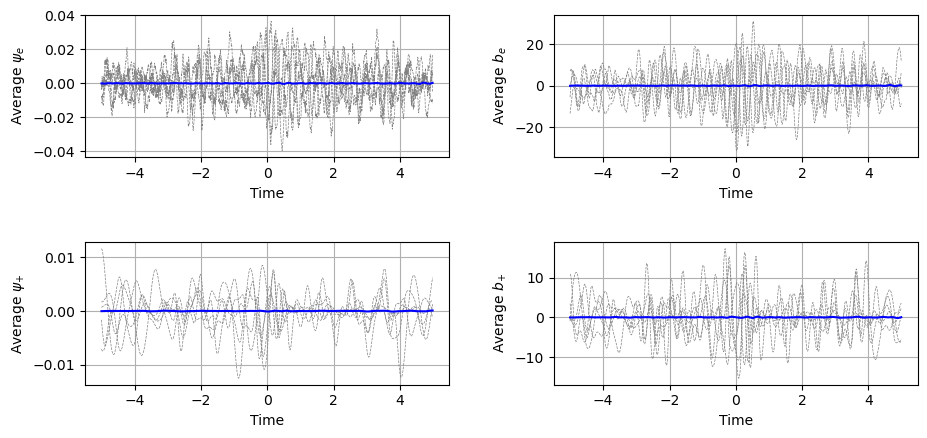

In [14]:
time_array = np.arange(-window_size/10, window_size/10) * dt * 10

fig, axs = plt.subplots(2, 2, figsize=(10, 5))

for i in range(5):
    axs[0, 0].plot(time_array, df['psi_e'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0, 0].plot(time_array, average_psi_e, label='Average', linewidth=1.5, color='blue')
axs[0, 0].set_ylabel(r'$\text{Average } \psi_{e}$')
axs[0, 0].set_xlabel('Time')
axs[0, 0].grid()


for i in range(5):
    axs[0, 1].plot(time_array, df['b_e'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0, 1].plot(time_array, average_b_e, label='Average', linewidth=1.5, color='blue')
axs[0, 1].set_ylabel(r'$\text{Average } b_{e}$')
axs[0, 1].set_xlabel('Time')
axs[0, 1].grid()

for i in range(5):
    axs[1, 0].plot(time_array, df['psi_plus'][i],linewidth=0.5, linestyle='--', color='gray') 
axs[1, 0].plot(time_array, average_psi_plus, label='Average', linewidth=1.5, color='blue')
axs[1, 0].set_ylabel(r'$\text{Average } \psi_{+}$')
axs[1, 0].set_xlabel('Time')
axs[1, 0].grid()

for i in range(5):
    axs[1, 1].plot(time_array, df['b_plus'][i], linewidth=0.5, linestyle='--', color='gray')
axs[1, 1].plot(time_array, average_b_plus, label='Average', linewidth=1.5, color='blue')
axs[1, 1].set_ylabel(r'$\text{Average } b_{+}$')
axs[1, 1].set_xlabel('Time')
axs[1, 1].grid()

plt.subplots_adjust(wspace=0.3, hspace=0.3, top=1.85)

plt.tight_layout(pad = 3)

plt.show()


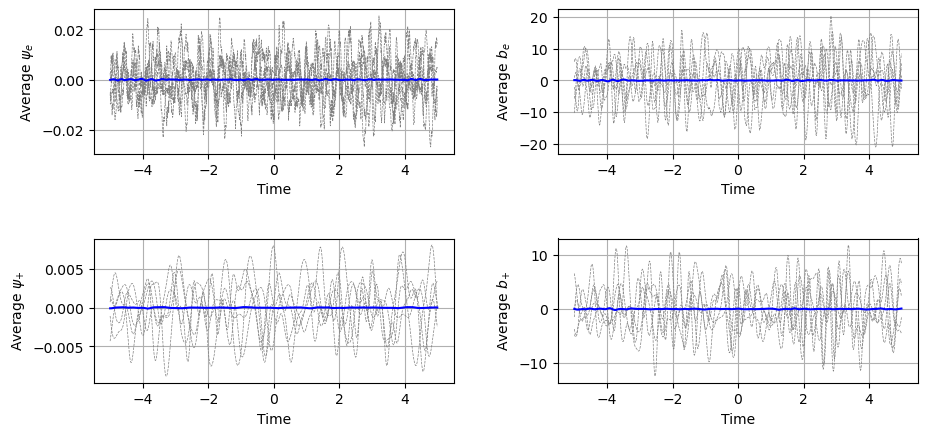

In [15]:
time_array = np.arange(-window_size/10, window_size/10) * dt * 10

fig, axs = plt.subplots(2, 2, figsize=(10, 5))

for i in range(5):
    axs[0, 0].plot(time_array, df1['psi_e'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0, 0].plot(time_array, average_psi_e_1, label='Average', linewidth=1.5, color='blue')
axs[0, 0].set_ylabel(r'$\text{Average } \psi_{e}$')
axs[0, 0].set_xlabel('Time')
axs[0, 0].grid()


for i in range(5):
    axs[0, 1].plot(time_array, df1['b_e'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0, 1].plot(time_array, average_b_e_1, label='Average', linewidth=1.5, color='blue')
axs[0, 1].set_ylabel(r'$\text{Average } b_{e}$')
axs[0, 1].set_xlabel('Time')
axs[0, 1].grid()

for i in range(5):
    axs[1, 0].plot(time_array, df1['psi_plus'][i],linewidth=0.5, linestyle='--', color='gray') 
axs[1, 0].plot(time_array, average_psi_plus_1, label='Average', linewidth=1.5, color='blue')
axs[1, 0].set_ylabel(r'$\text{Average } \psi_{+}$')
axs[1, 0].set_xlabel('Time')
axs[1, 0].grid()

for i in range(5):
    axs[1, 1].plot(time_array, df1['b_plus'][i], linewidth=0.5, linestyle='--', color='gray')
axs[1, 1].plot(time_array, average_b_plus_1, label='Average', linewidth=1.5, color='blue')
axs[1, 1].set_ylabel(r'$\text{Average } b_{+}$')
axs[1, 1].set_xlabel('Time')
axs[1, 1].grid()

plt.subplots_adjust(wspace=0.3, hspace=0.3, top=1.85)

plt.tight_layout(pad = 3)

plt.show()


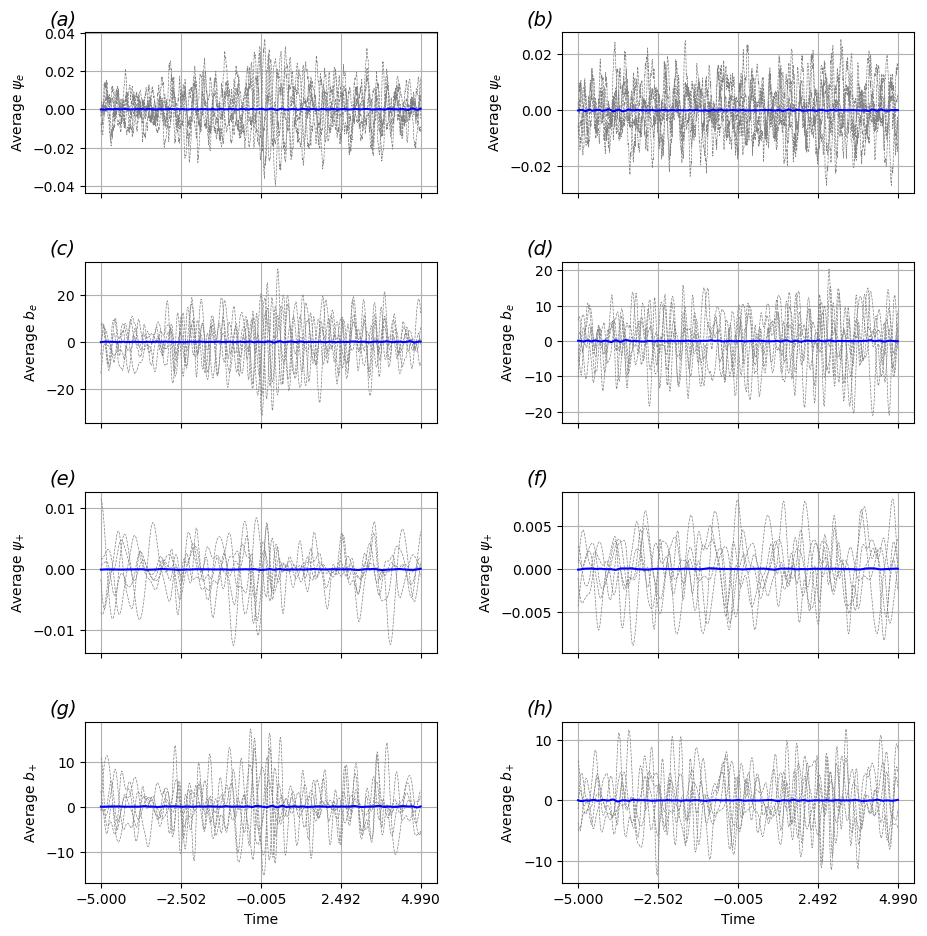

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from string import ascii_lowercase

def jfm_panel_labels(axes, x=-0.10, y=1.02, start=0, **kwargs):
    """
    Add (a), (b), ... to a list/array of axes in JFM style.
    """
    axes = np.ravel(axes)

    defaults = dict(
        fontsize=14,
        fontstyle='italic',
        va='bottom',
        ha='left'
    )
    defaults.update(kwargs)

    for i, ax in enumerate(axes[start:], start=start):
        label = f'({ascii_lowercase[i]})'
        ax.text(x, y, label, transform=ax.transAxes, **defaults)


time_array = np.arange(-window_size/10, window_size/10) * dt * 10

# 4 rows x 2 cols:
# left column = first dataset (df)
# right column = second dataset (df1)
fig, axs = plt.subplots(4, 2, figsize=(10, 10), sharex=True)

# ---------- Row 1: psi_e ----------
ax = axs[0, 0]
for i in range(5):
    ax.plot(time_array, df['psi_e'][i], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_array, average_psi_e, label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'$\text{Average } \psi_{e}$')
ax.grid()

ax = axs[0, 1]
for i in range(5):
    ax.plot(time_array, df1['psi_e'][i], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_array, average_psi_e_1, label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'$\text{Average } \psi_{e}$')
ax.grid()

# ---------- Row 2: b_e ----------
ax = axs[1, 0]
for i in range(5):
    ax.plot(time_array, df['b_e'][i], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_array, average_b_e, label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'$\text{Average } b_{e}$')
ax.grid()

ax = axs[1, 1]
for i in range(5):
    ax.plot(time_array, df1['b_e'][i], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_array, average_b_e_1, label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'$\text{Average } b_{e}$')
ax.grid()

# ---------- Row 3: psi_plus ----------
ax = axs[2, 0]
for i in range(5):
    ax.plot(time_array, df['psi_plus'][i], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_array, average_psi_plus, label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'$\text{Average } \psi_{+}$')
ax.grid()

ax = axs[2, 1]
for i in range(5):
    ax.plot(time_array, df1['psi_plus'][i], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_array, average_psi_plus_1, label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'$\text{Average } \psi_{+}$')
ax.grid()

# ---------- Row 4: b_plus ----------
ax = axs[3, 0]
for i in range(5):
    ax.plot(time_array, df['b_plus'][i], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_array, average_b_plus, label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'$\text{Average } b_{+}$')
ax.set_xlabel('Time')
ax.grid()

ax = axs[3, 1]
for i in range(5):
    ax.plot(time_array, df1['b_plus'][i], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_array, average_b_plus_1, label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'$\text{Average } b_{+}$')
ax.set_xlabel('Time')
ax.grid()

# common x-ticks (optional)
for ax in axs.ravel():
    ax.set_xticks(np.linspace(time_array[0], time_array[-1], 5))

# panel labels (a)–(h)
jfm_panel_labels(axs)

plt.tight_layout(pad=3)
plt.show()


#make everything symmetric around y=0 for better comparison
#Talk about this figure later, might wanna cut things
#get rid of all the padding and white space and the y axis labels on the right hand side. make it clear what the left and right columns are
#by having a title at the top of each column

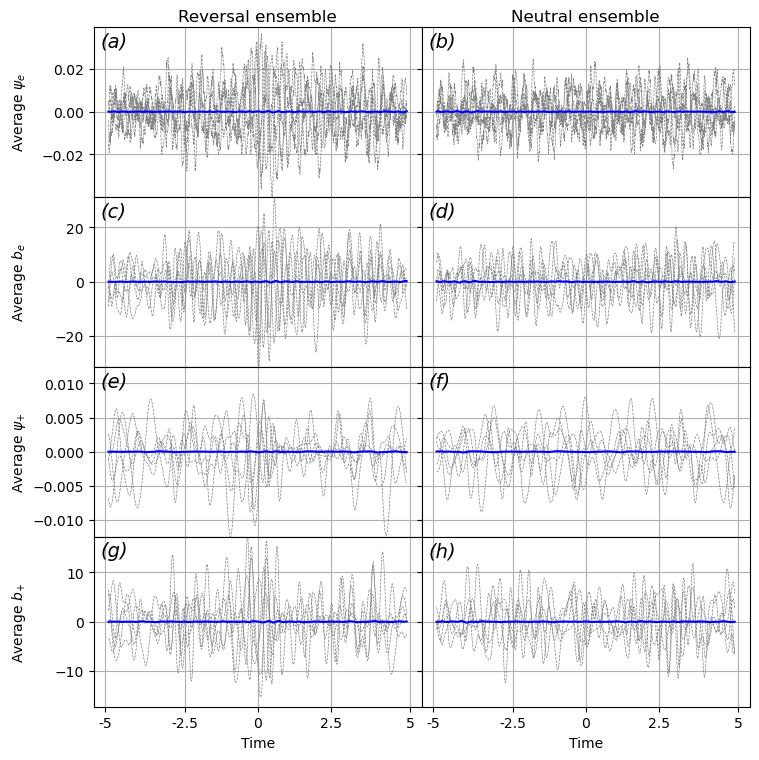

In [17]:
time_array = np.arange(-window_size/10, window_size/10) * dt * 10

fig, axs = plt.subplots(
    4, 2,
    figsize=(8, 8),
    sharex=True,
    gridspec_kw={'hspace': 0, 'wspace': 0}
)

# small trim so the blue average line doesn't span full [-5, 5]
trim = 30
time_avg = time_array[trim:-trim]

# ---------- Row 1: psi_e ----------
ax = axs[0, 0]
for i in range(5):
    ax.plot(time_avg, df['psi_e'][i][trim:-trim], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_psi_e[trim:-trim], label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'Average $\psi_{e}$')
ax.grid()

ax = axs[0, 1]
for i in range(5):
    ax.plot(time_avg, df1['psi_e'][i][trim:-trim], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_psi_e_1[trim:-trim], label='Average', linewidth=1.5, color='blue')
# no ylabel on the right
ax.set_ylabel('')
ax.grid()

# ---------- Row 2: b_e ----------
ax = axs[1, 0]
for i in range(5):
    ax.plot(time_avg, df['b_e'][i][trim:-trim], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_b_e[trim:-trim], label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'Average $b_{e}$')
ax.grid()

ax = axs[1, 1]
for i in range(5):
    ax.plot(time_avg, df1['b_e'][i][trim:-trim], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_b_e_1[trim:-trim], label='Average', linewidth=1.5, color='blue')
ax.set_ylabel('')
ax.grid()

# ---------- Row 3: psi_plus ----------
ax = axs[2, 0]
for i in range(5):
    ax.plot(time_avg, df['psi_plus'][i][trim:-trim], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_psi_plus[trim:-trim], label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'Average $\psi_{+}$')
ax.grid()

ax = axs[2, 1]
for i in range(5):
    ax.plot(time_avg, df1['psi_plus'][i][trim:-trim], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_psi_plus_1[trim:-trim], label='Average', linewidth=1.5, color='blue')
ax.set_ylabel('')
ax.grid()

# ---------- Row 4: b_plus ----------
ax = axs[3, 0]
for i in range(5):
    ax.plot(time_avg, df['b_plus'][i][trim:-trim], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_b_plus[trim:-trim], label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'Average $b_{+}$')
ax.set_xlabel('Time')
ax.grid()

ax = axs[3, 1]
for i in range(5):
    ax.plot(time_avg, df1['b_plus'][i][trim:-trim], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_b_plus_1[trim:-trim], label='Average', linewidth=1.5, color='blue')
ax.set_ylabel('')
ax.set_xlabel('Time')
ax.grid()

# ---------- X-axis: keep time from -5 to 5 ----------
# xticks = [-5, -2.5, 0, 2.5, 5]
# for ax in axs.ravel():
#     ax.set_xlim(-5, 5)
#     ax.set_xticks(xticks)
# ---------- X-axis: use the trimmed time range ----------
positions = [-4.8, -2.3, 0, 2.3, 4.8]
labels    = ['-5', '-2.5', '0', '2.5', '5']

for ax in axs.ravel():
    ax.set_xticks(positions)
    ax.set_xticklabels(labels)






# ---------- Y-axis: symmetric per row, shared L/R ----------
for row in range(4):
    left_ax = axs[row, 0]
    right_ax = axs[row, 1]
    ys = []

    for ax in (left_ax, right_ax):
        for line in ax.get_lines():
            y = line.get_ydata()
            y = y[np.isfinite(y)]
            if y.size:
                ys.append(y)

    if ys:
        ys_all = np.concatenate(ys)
        max_abs = np.max(np.abs(ys_all))
        left_ax.set_ylim(-max_abs, max_abs)
        right_ax.set_ylim(-max_abs, max_abs)

# remove y tick labels on the right column
for row in range(4):
    axs[row, 1].tick_params(labelleft=False)

# ---------- Column titles ----------
axs[0, 0].set_title('Reversal ensemble', pad=4)
axs[0, 1].set_title('Neutral ensemble', pad=4)

# ---------- Align all left y-labels horizontally ----------
for ax in axs[:, 0]:
    ax.yaxis.set_label_coords(-0.20, 0.5)  # adjust -0.12 as needed

# ---------- Panel labels slightly lower inside ----------
jfm_panel_labels(axs, x=0.02, y=0.86)

# ---------- Panels touching (tiny outer margins for labels) ----------
fig.subplots_adjust(
    left=0.16,   # room for aligned y-labels
    right=0.98,
    top=0.93,
    bottom=0.08,
    wspace=0.0,
    hspace=0.0
)

plt.show()


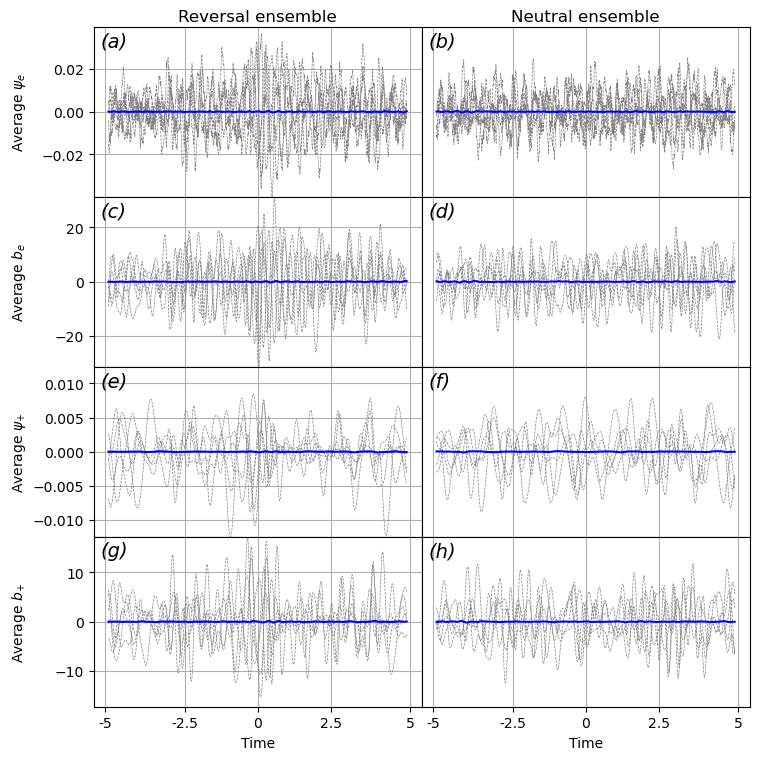

In [18]:
import matplotlib.pyplot as plt
import numpy as np

time_array = np.arange(-window_size/10, window_size/10) * dt * 10

fig, axs = plt.subplots(
    4, 2,
    figsize=(8, 8),
    sharex=True,
    gridspec_kw={'hspace': 0, 'wspace': 0}
)

# small trim so the blue average line doesn't span full [-5, 5]
trim = 30
time_avg = time_array[trim:-trim]

# ---------- Row 1: psi_e ----------
ax = axs[0, 0]
for i in range(5):
    ax.plot(time_avg, df['psi_e'][i][trim:-trim], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_psi_e[trim:-trim], label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'Average $\psi_{e}$')
ax.grid()

ax = axs[0, 1]
for i in range(5):
    ax.plot(time_avg, df1['psi_e'][i][trim:-trim], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_psi_e_1[trim:-trim], label='Average', linewidth=1.5, color='blue')
ax.set_ylabel('')
ax.grid()

# ---------- Row 2: b_e ----------
ax = axs[1, 0]
for i in range(5):
    ax.plot(time_avg, df['b_e'][i][trim:-trim], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_b_e[trim:-trim], label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'Average $b_{e}$')
ax.grid()

ax = axs[1, 1]
for i in range(5):
    ax.plot(time_avg, df1['b_e'][i][trim:-trim], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_b_e_1[trim:-trim], label='Average', linewidth=1.5, color='blue')
ax.set_ylabel('')
ax.grid()

# ---------- Row 3: psi_plus ----------
ax = axs[2, 0]
for i in range(5):
    ax.plot(time_avg, df['psi_plus'][i][trim:-trim], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_psi_plus[trim:-trim], label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'Average $\psi_{+}$')
ax.grid()

ax = axs[2, 1]
for i in range(5):
    ax.plot(time_avg, df1['psi_plus'][i][trim:-trim], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_psi_plus_1[trim:-trim], label='Average', linewidth=1.5, color='blue')
ax.set_ylabel('')
ax.grid()

# ---------- Row 4: b_plus ----------
ax = axs[3, 0]
for i in range(5):
    ax.plot(time_avg, df['b_plus'][i][trim:-trim], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_b_plus[trim:-trim], label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'Average $b_{+}$')
ax.set_xlabel('Time')
ax.grid()

ax = axs[3, 1]
for i in range(5):
    ax.plot(time_avg, df1['b_plus'][i][trim:-trim], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_b_plus_1[trim:-trim], label='Average', linewidth=1.5, color='blue')
ax.set_ylabel('')
ax.set_xlabel('Time')
ax.grid()

# ---------- X-axis: use the trimmed time range ----------
positions = [-4.8, -2.3, 0, 2.3, 4.8]
labels    = ['-5', '-2.5', '0', '2.5', '5']

for ax in axs.ravel():
    ax.set_xticks(positions)
    ax.set_xticklabels(labels)

# ---------- Y-axis: symmetric per row, shared L/R ----------
for row in range(4):
    left_ax = axs[row, 0]
    right_ax = axs[row, 1]
    ys = []

    for ax in (left_ax, right_ax):
        for line in ax.get_lines():
            y = line.get_ydata()
            y = y[np.isfinite(y)]
            if y.size:
                ys.append(y)

    if ys:
        ys_all = np.concatenate(ys)
        max_abs = np.max(np.abs(ys_all))
        left_ax.set_ylim(-max_abs, max_abs)
        right_ax.set_ylim(-max_abs, max_abs)

# ---------- remove y ticks & labels on the right column ----------
for row in range(4):
    axs[row, 1].tick_params(left=False, labelleft=False)
    axs[row, 1].set_yticks([])

# ---------- Column titles ----------
axs[0, 0].set_title('Reversal ensemble', pad=4)
axs[0, 1].set_title('Neutral ensemble', pad=4)

# ---------- Align all left y-labels horizontally ----------
for ax in axs[:, 0]:
    ax.yaxis.set_label_coords(-0.20, 0.5)  # adjust as needed

# ---------- Panel labels slightly lower inside ----------
jfm_panel_labels(axs, x=0.02, y=0.86)

# ---------- Panels touching (tiny outer margins for labels) ----------
fig.subplots_adjust(
    left=0.16,   # room for aligned y-labels
    right=0.98,
    top=0.93,
    bottom=0.08,
    wspace=0.0,
    hspace=0.0
)

plt.show()


U and R values

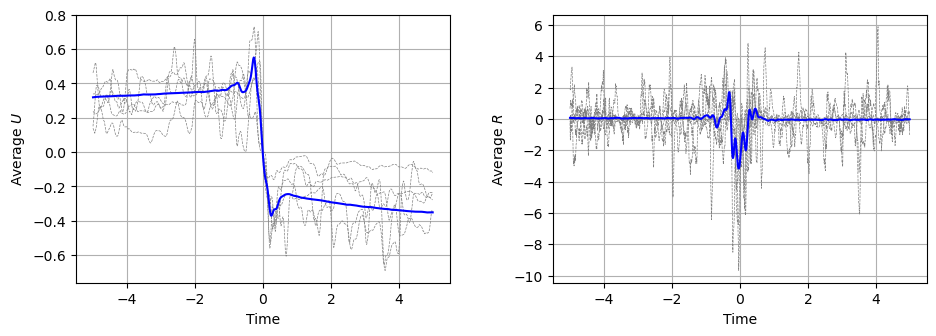

In [18]:
# Define the time array
time_array = np.arange(-window_size / 10, window_size / 10) * dt * 10

# Create a 1x2 subplot layout
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Plot U
for i in range(5):
    axs[0].plot(time_array, df['u_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0].plot(time_array, average_U, label='Average', linewidth=1.5, color='blue')
axs[0].set_ylabel(r'$\text{Average } U$')
axs[0].set_xlabel('Time')
axs[0].grid()

# Plot R
for i in range(5):
    axs[1].plot(time_array, df['r_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[1].plot(time_array, average_R, label='Average', linewidth=1.5, color='blue')
axs[1].set_ylabel(r'$\text{Average } R$')
axs[1].set_xlabel('Time')
axs[1].grid()

# Adjust layout
plt.tight_layout(pad=3)
plt.show()


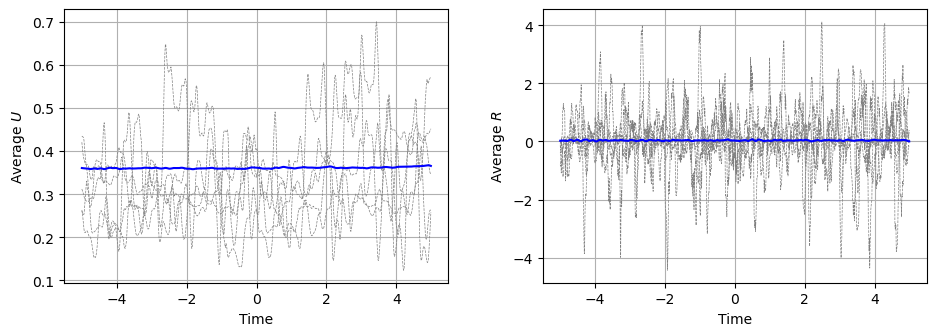

ValueError: x and y must have same first dimension, but have shapes (60,) and (660,)

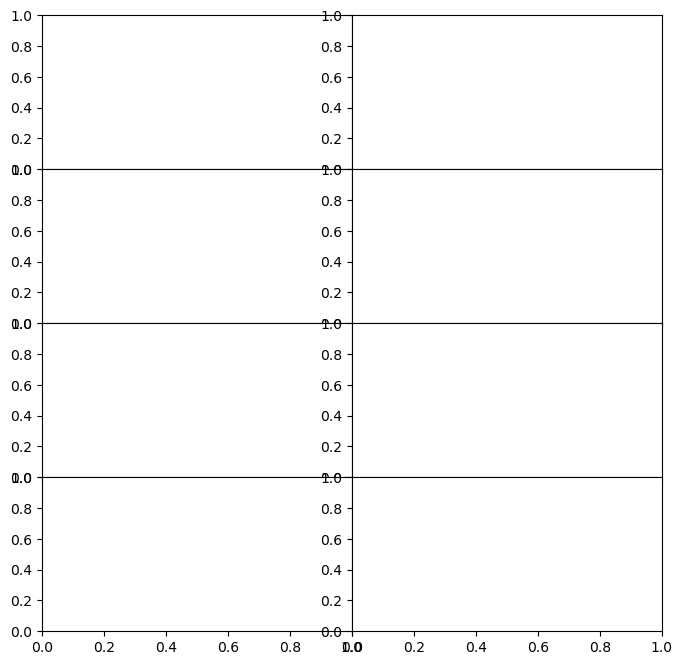

In [20]:
# Define the time array
time_array = np.arange(-window_size / 10, window_size / 10) * dt * 10

# Create a 1x2 subplot layout
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Plot U
for i in range(5):
    axs[0].plot(time_array, df1['u_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0].plot(time_array, average_U_1, label='Average', linewidth=1.5, color='blue')
axs[0].set_ylabel(r'$\text{Average } U$')
axs[0].set_xlabel('Time')
axs[0].grid()

# Plot R
for i in range(5):
    axs[1].plot(time_array, df1['r_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[1].plot(time_array, average_R_1, label='Average', linewidth=1.5, color='blue')
axs[1].set_ylabel(r'$\text{Average } R$')
axs[1].set_xlabel('Time')
axs[1].grid()

# Adjust layout
plt.tight_layout(pad=3)
plt.show()
# Time array (full resolution)
time_array = np.arange(-window_size/10, window_size/10) * dt * 10

fig, axs = plt.subplots(
    4, 2,
    figsize=(8, 8),
    sharex=True,
    gridspec_kw={'hspace': 0, 'wspace': 0}
)

# ----- Subsample & trim settings -----
step = 10          # decimate by 10
offset = 9         # so indices 9, 19, 29, ...
trim = 20          # trim on the *subsampled* arrays

# Subsample time, then trim
time_sub = time_array[offset::step]
time_avg = time_sub[trim:-trim]

# Helper to subsample then trim any 1D array-like
def subsample_and_trim(arr, offset=offset, step=step, trim=trim):
    arr_sub = np.asarray(arr)[offset::step]
    if trim > 0:
        arr_sub = arr_sub[trim:-trim]
    return arr_sub

# Precompute all subsampled & trimmed series

# Reversal ensemble
psi_e_rev   = subsample_and_trim(df['psi_e'])
b_e_rev     = subsample_and_trim(df['b_e'])
psi_p_rev   = subsample_and_trim(df['psi_plus'])
b_p_rev     = subsample_and_trim(df['b_plus'])

avg_psi_e_rev = subsample_and_trim(average_psi_e)
avg_b_e_rev   = subsample_and_trim(average_b_e)
avg_psi_p_rev = subsample_and_trim(average_psi_plus)
avg_b_p_rev   = subsample_and_trim(average_b_plus)

# Neutral ensemble
psi_e_neu   = subsample_and_trim(df1['psi_e'])
b_e_neu     = subsample_and_trim(df1['b_e'])
psi_p_neu   = subsample_and_trim(df1['psi_plus'])
b_p_neu     = subsample_and_trim(df1['b_plus'])

avg_psi_e_neu = subsample_and_trim(average_psi_e_1)
avg_b_e_neu   = subsample_and_trim(average_b_e_1)
avg_psi_p_neu = subsample_and_trim(average_psi_plus_1)
avg_b_p_neu   = subsample_and_trim(average_b_plus_1)

# ---------- Row 1: psi_e ----------
ax = axs[0, 0]
for i in range(5):
    ax.plot(time_avg, psi_e_rev, linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, avg_psi_e_rev, label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'Average $\psi_{e}$')
ax.grid()

ax = axs[0, 1]
for i in range(5):
    ax.plot(time_avg, psi_e_neu, linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, avg_psi_e_neu, label='Average', linewidth=1.5, color='blue')
ax.set_ylabel('')
ax.grid()

# ---------- Row 2: b_e ----------
ax = axs[1, 0]
for i in range(5):
    ax.plot(time_avg, b_e_rev, linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, avg_b_e_rev, label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'Average $b_{e}$')
ax.grid()

ax = axs[1, 1]
for i in range(5):
    ax.plot(time_avg, b_e_neu, linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, avg_b_e_neu, label='Average', linewidth=1.5, color='blue')
ax.set_ylabel('')
ax.grid()

# ---------- Row 3: psi_plus ----------
ax = axs[2, 0]
for i in range(5):
    ax.plot(time_avg, psi_p_rev, linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, avg_psi_p_rev, label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'Average $\psi_{+}$')
ax.grid()

ax = axs[2, 1]
for i in range(5):
    # fixed: use time_avg, not the full time_array
    ax.plot(time_avg, psi_p_neu, linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, avg_psi_p_neu, label='Average', linewidth=1.5, color='blue')
ax.set_ylabel('')
ax.grid()

# ---------- Row 4: b_plus ----------
ax = axs[3, 0]
for i in range(5):
    ax.plot(time_avg, b_p_rev, linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, avg_b_p_rev, label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'Average $b_{+}$')
ax.set_xlabel('Time')
ax.grid()

ax = axs[3, 1]
for i in range(5):
    ax.plot(time_avg, b_p_neu, linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, avg_b_p_neu, label='Average', linewidth=1.5, color='blue')
ax.set_ylabel('')
ax.set_xlabel('Time')
ax.grid()

# ---------- X-axis: keep time from -5 to 5 ----------
xticks = [-5, -2.5, 0, 2.5, 5]
for ax in axs.ravel():
    ax.set_xlim(-5, 5)
    ax.set_xticks(xticks)

# ---------- Y-axis: symmetric per row, shared L/R ----------
for row in range(4):
    left_ax = axs[row, 0]
    right_ax = axs[row, 1]
    ys = []

    for ax in (left_ax, right_ax):
        for line in ax.get_lines():
            y = line.get_ydata()
            y = y[np.isfinite(y)]
            if y.size:
                ys.append(y)

    if ys:
        ys_all = np.concatenate(ys)
        max_abs = np.max(np.abs(ys_all))
        left_ax.set_ylim(-max_abs, max_abs)
        right_ax.set_ylim(-max_abs, max_abs)

# remove y tick labels on the right column
for row in range(4):
    axs[row, 1].tick_params(labelleft=False)

# ---------- Column titles ----------
axs[0, 0].set_title('Reversal ensemble', pad=4)
axs[0, 1].set_title('Neutral ensemble', pad=4)

# ---------- Align all left y-labels horizontally ----------
for ax in axs[:, 0]:
    ax.yaxis.set_label_coords(-0.12, 0.5)

# ---------- Panel labels slightly lower inside ----------
jfm_panel_labels(axs, x=0.02, y=0.86)

# ---------- Panels touching (tiny outer margins for labels) ----------
fig.subplots_adjust(
    left=0.16,   # room for aligned y-labels
    right=0.98,
    top=0.93,
    bottom=0.08,
    wspace=0.0,
    hspace=0.0
)

plt.show()

#Figure this plot out

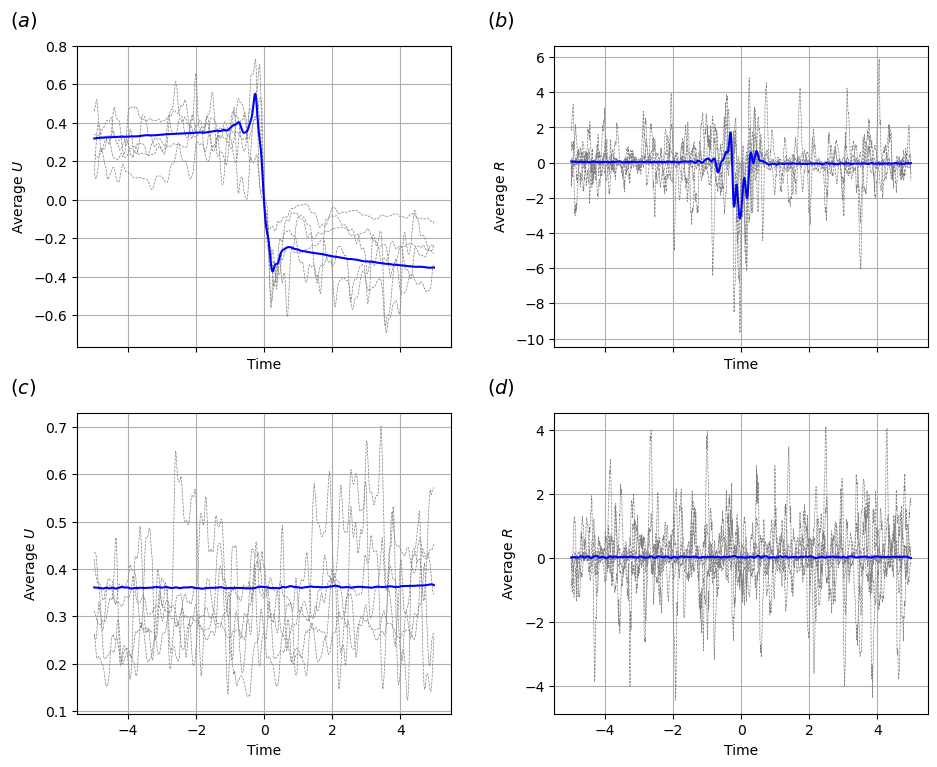

In [ ]:
# Define the time array
time_array = np.arange(-window_size / 10, window_size / 10) * dt * 10

fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True)

# ---------------- Row 1: first dataset (df) ----------------
# U
ax = axs[0, 0]
for i in range(5):
    ax.plot(time_array, df['u_list'][i], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_array, average_U, label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'Average $U$')
ax.set_xlabel('Time')
ax.grid()

# R
ax = axs[0, 1]
for i in range(5):
    ax.plot(time_array, df['r_list'][i], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_array, average_R, label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'Average $R$')
ax.set_xlabel('Time')
ax.grid()

# ---------------- Row 2: second dataset (df1) ----------------
# U
ax = axs[1, 0]
for i in range(5):
    ax.plot(time_array, df1['u_list'][i], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_array, average_U_1, label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'Average $U$')
ax.set_xlabel('Time')
ax.grid()

# R
ax = axs[1, 1]
for i in range(5):
    ax.plot(time_array, df1['r_list'][i], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_array, average_R_1, label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'Average $R$')
ax.set_xlabel('Time')
ax.grid()

# Tight layout *first* so axes are placed, then add labels
plt.tight_layout(pad=3)

# ---------- put (a), (b), (c), (d) OUTSIDE the axes ----------
labels = [r'$(a)$', r'$(b)$', r'$(c)$', r'$(d)$']
for ax, lab in zip(axs.ravel(), labels):
    ax.text(
        -0.18, 1.05, lab,              # x<0, y>1 -> outside plot area
        transform=ax.transAxes,
        fontsize=14,
        fontstyle='italic',
        va='bottom',
        ha='left'
    )

plt.show()


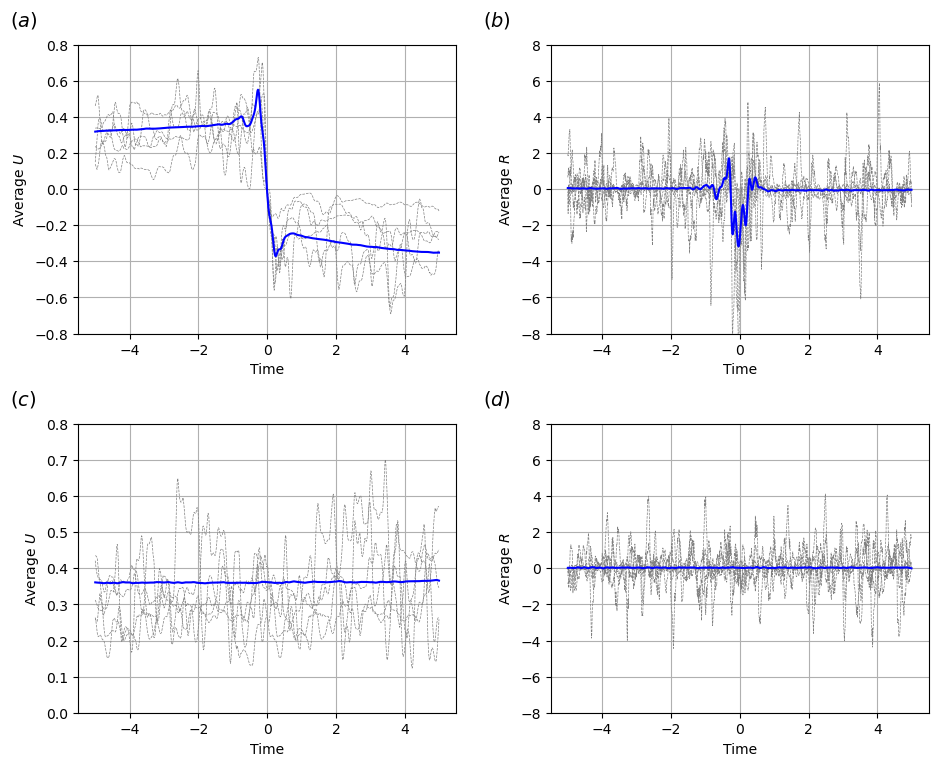

In [ ]:
# Define the time array
time_array = np.arange(-window_size / 10, window_size / 10) * dt * 10

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# ---------------- Row 1: first dataset (df) ----------------
# U  -> panel (a)
ax = axs[0, 0]
for i in range(5):
    ax.plot(time_array, df['u_list'][i], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_array, average_U, label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'Average $U$')
ax.set_xlabel('Time')
ax.grid()

# R  -> panel (b)
ax = axs[0, 1]
for i in range(5):
    ax.plot(time_array, df['r_list'][i], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_array, average_R, label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'Average $R$')
ax.set_xlabel('Time')
ax.grid()

# ---------------- Row 2: second dataset (df1) ----------------
# U  -> panel (c)
ax = axs[1, 0]
for i in range(5):
    ax.plot(time_array, df1['u_list'][i], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_array, average_U_1, label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'Average $U$')
ax.set_xlabel('Time')
ax.grid()

# R  -> panel (d)
ax = axs[1, 1]
for i in range(5):
    ax.plot(time_array, df1['r_list'][i], linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_array, average_R_1, label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'Average $R$')
ax.set_xlabel('Time')
ax.grid()

# ---------- Set custom y-limits ----------
# (a): -0.8 to 0.8
axs[0, 0].set_ylim(-0.8, 0.8)

# (b): -8 to 8
axs[0, 1].set_ylim(-8, 8)

# (c): 0 to 0.8
axs[1, 0].set_ylim(0.0, 0.8)

# (d): -8 to 8
axs[1, 1].set_ylim(-8, 8)

# Tight layout *first* so axes are placed, then add labels
plt.tight_layout(pad=3)

# ---------- put (a), (b), (c), (d) OUTSIDE the axes ----------
labels = [r'$(a)$', r'$(b)$', r'$(c)$', r'$(d)$']
for ax, lab in zip(axs.ravel(), labels):
    ax.text(
        -0.18, 1.05, lab,              # x<0, y>1 -> outside plot area
        transform=ax.transAxes,
        fontsize=14,
        fontstyle='italic',
        va='bottom',
        ha='left'
    )

plt.show()


KE variables

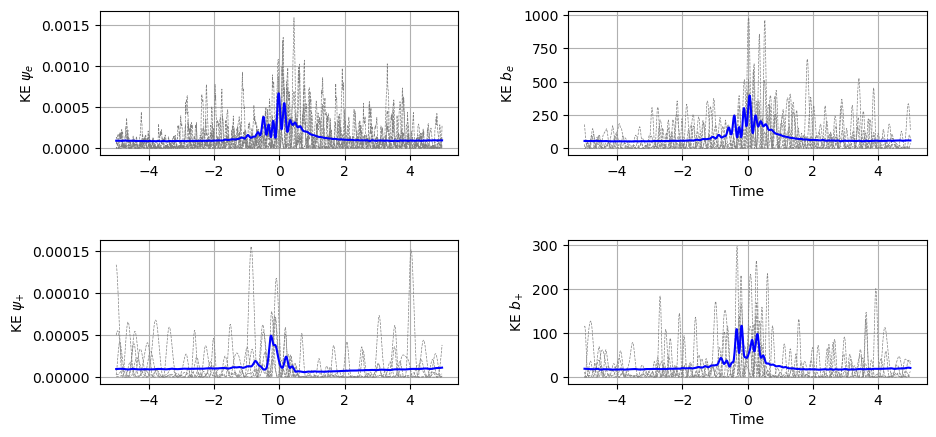

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define the time array
time_array = np.arange(-window_size / 10, window_size / 10) * dt * 10

# Create a 2x2 subplot layout
fig, axs = plt.subplots(2, 2, figsize=(10, 5))

# KE psi_e
for i in range(5):
    axs[0, 0].plot(time_array, df['k_e_psi_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0, 0].plot(time_array, average_k_e_psi_e_list, label='Average', linewidth=1.5, color='blue')
axs[0, 0].set_ylabel(r'$\text{KE } \psi_{e}$')
axs[0, 0].set_xlabel('Time')
axs[0, 0].grid()

# KE b_e
for i in range(5):
    axs[0, 1].plot(time_array, df['k_e_b_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0, 1].plot(time_array, average_k_e_b_e_list, label='Average', linewidth=1.5, color='blue')
axs[0, 1].set_ylabel(r'$\text{KE } b_{e}$')
axs[0, 1].set_xlabel('Time')
axs[0, 1].grid()

# KE psi_plus
for i in range(5):
    axs[1, 0].plot(time_array, df['k_e_psi_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[1, 0].plot(time_array, average_k_e_psi_plus_list, label='Average', linewidth=1.5, color='blue')
axs[1, 0].set_ylabel(r'$\text{KE } \psi_{+}$')
axs[1, 0].set_xlabel('Time')
axs[1, 0].grid()

# KE b_plus
for i in range(5):
    axs[1, 1].plot(time_array, df['k_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[1, 1].plot(time_array, average_k_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
axs[1, 1].set_ylabel(r'$\text{KE } b_{+}$')
axs[1, 1].set_xlabel('Time')
axs[1, 1].grid()

# Layout adjustments
plt.tight_layout(pad=3)
plt.show()



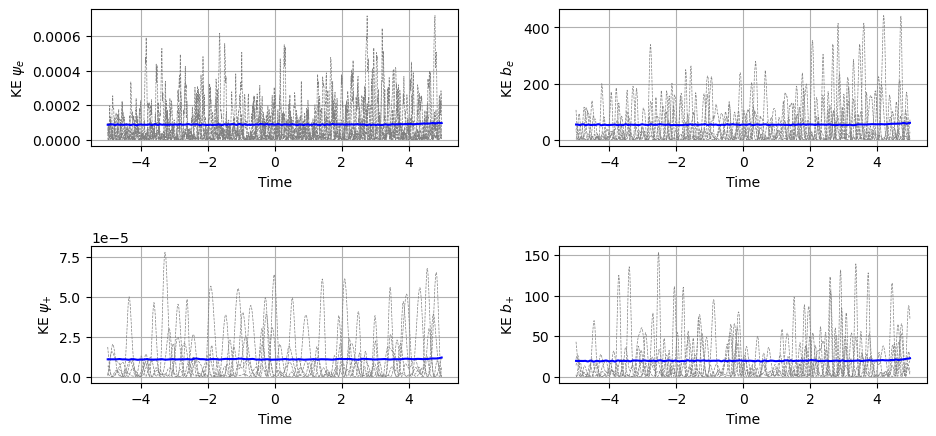

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define the time array
time_array = np.arange(-window_size / 10, window_size / 10) * dt * 10

# Create a 2x2 subplot layout
fig, axs = plt.subplots(2, 2, figsize=(10, 5))

# KE psi_e
for i in range(5):
    axs[0, 0].plot(time_array, df1['k_e_psi_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0, 0].plot(time_array, average_k_e_psi_e_list_1, label='Average', linewidth=1.5, color='blue')
axs[0, 0].set_ylabel(r'$\text{KE } \psi_{e}$')
axs[0, 0].set_xlabel('Time')
axs[0, 0].grid()

# KE b_e
for i in range(5):
    axs[0, 1].plot(time_array, df1['k_e_b_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0, 1].plot(time_array, average_k_e_b_e_list_1, label='Average', linewidth=1.5, color='blue')
axs[0, 1].set_ylabel(r'$\text{KE } b_{e}$')
axs[0, 1].set_xlabel('Time')
axs[0, 1].grid()

# KE psi_plus
for i in range(5):
    axs[1, 0].plot(time_array, df1['k_e_psi_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[1, 0].plot(time_array, average_k_e_psi_plus_list_1, label='Average', linewidth=1.5, color='blue')
axs[1, 0].set_ylabel(r'$\text{KE } \psi_{+}$')
axs[1, 0].set_xlabel('Time')
axs[1, 0].grid()

# KE b_plus
for i in range(5):
    axs[1, 1].plot(time_array, df1['k_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[1, 1].plot(time_array, average_k_e_b_plus_list_1, label='Average', linewidth=1.5, color='blue')
axs[1, 1].set_ylabel(r'$\text{KE } b_{+}$')
axs[1, 1].set_xlabel('Time')
axs[1, 1].grid()

# Layout adjustments
plt.tight_layout(pad=3)
plt.show()


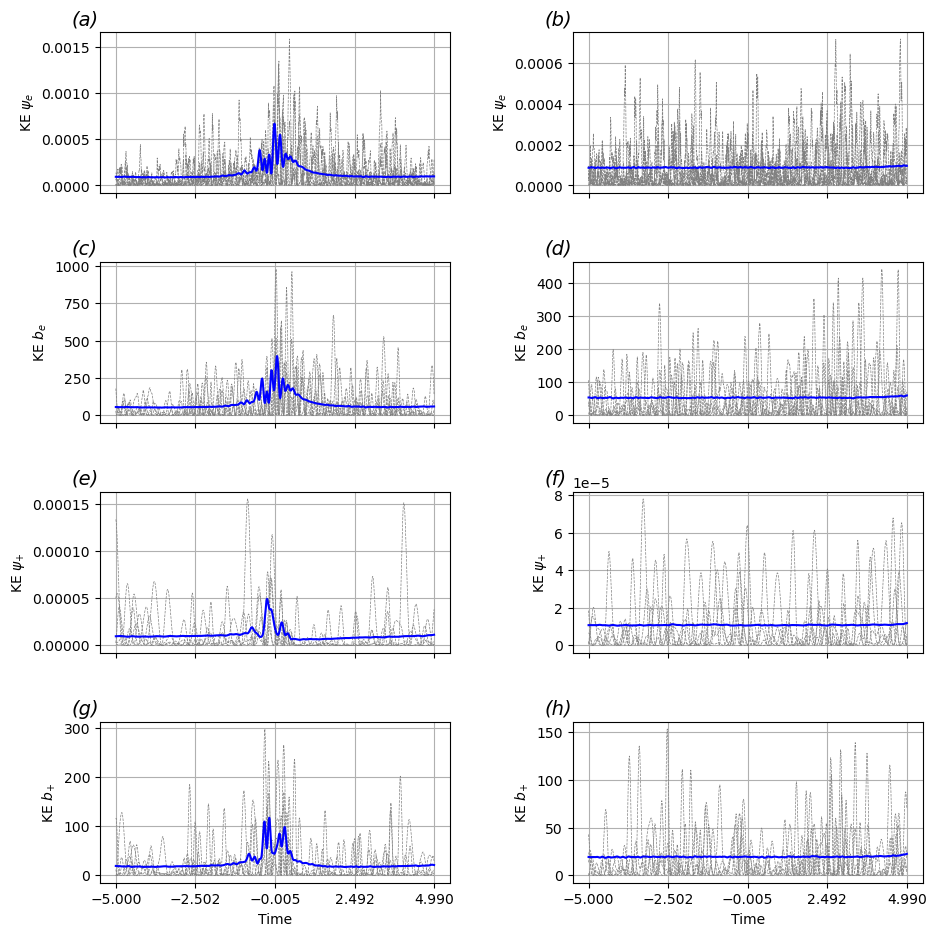

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from string import ascii_lowercase

def jfm_panel_labels(axes, x=-0.10, y=1.02, start=0, **kwargs):
    """
    Add (a), (b), ... to a list/array of axes in JFM style.
    """
    axes = np.ravel(axes)

    defaults = dict(
        fontsize=14,
        fontstyle='italic',
        va='bottom',
        ha='left'
    )
    defaults.update(kwargs)

    for i, ax in enumerate(axes[start:], start=start):
        label = f'({ascii_lowercase[i]})'
        ax.text(x, y, label, transform=ax.transAxes, **defaults)


# ---- your KE figure ----
time_array = np.arange(-window_size / 10, window_size / 10) * dt * 10

# 4 rows x 2 cols: left = df, right = df1
fig, axs = plt.subplots(4, 2, figsize=(10, 10), sharex=True)

# # Optional column titles
# axs[0, 0].set_title('Case 1')
# axs[0, 1].set_title('Case 2')

# ---------- Row 1: KE psi_e ----------
ax = axs[0, 0]
for i in range(5):
    ax.plot(time_array, df['k_e_psi_e_list'][i], linewidth=0.5,
            linestyle='--', color='gray')
ax.plot(time_array, average_k_e_psi_e_list, label='Average',
        linewidth=1.5, color='blue')
ax.set_ylabel(r'$\text{KE } \psi_{e}$')
ax.grid()

ax = axs[0, 1]
for i in range(5):
    ax.plot(time_array, df1['k_e_psi_e_list'][i], linewidth=0.5,
            linestyle='--', color='gray')
ax.plot(time_array, average_k_e_psi_e_list_1, label='Average',
        linewidth=1.5, color='blue')
ax.set_ylabel(r'$\text{KE } \psi_{e}$')
ax.grid()

# ---------- Row 2: KE b_e ----------
ax = axs[1, 0]
for i in range(5):
    ax.plot(time_array, df['k_e_b_e_list'][i], linewidth=0.5,
            linestyle='--', color='gray')
ax.plot(time_array, average_k_e_b_e_list, label='Average',
        linewidth=1.5, color='blue')
ax.set_ylabel(r'$\text{KE } b_{e}$')
ax.grid()

ax = axs[1, 1]
for i in range(5):
    ax.plot(time_array, df1['k_e_b_e_list'][i], linewidth=0.5,
            linestyle='--', color='gray')
ax.plot(time_array, average_k_e_b_e_list_1, label='Average',
        linewidth=1.5, color='blue')
ax.set_ylabel(r'$\text{KE } b_{e}$')
ax.grid()

# ---------- Row 3: KE psi_plus ----------
ax = axs[2, 0]
for i in range(5):
    ax.plot(time_array, df['k_e_psi_plus_list'][i], linewidth=0.5,
            linestyle='--', color='gray')
ax.plot(time_array, average_k_e_psi_plus_list, label='Average',
        linewidth=1.5, color='blue')
ax.set_ylabel(r'$\text{KE } \psi_{+}$')
ax.grid()

ax = axs[2, 1]
for i in range(5):
    ax.plot(time_array, df1['k_e_psi_plus_list'][i], linewidth=0.5,
            linestyle='--', color='gray')
ax.plot(time_array, average_k_e_psi_plus_list_1, label='Average',
        linewidth=1.5, color='blue')
ax.set_ylabel(r'$\text{KE } \psi_{+}$')
ax.grid()

# ---------- Row 4: KE b_plus ----------
ax = axs[3, 0]
for i in range(5):
    ax.plot(time_array, df['k_e_b_plus_list'][i], linewidth=0.5,
            linestyle='--', color='gray')
ax.plot(time_array, average_k_e_b_plus_list, label='Average',
        linewidth=1.5, color='blue')
ax.set_ylabel(r'$\text{KE } b_{+}$')
ax.set_xlabel('Time')
ax.grid()

ax = axs[3, 1]
for i in range(5):
    ax.plot(time_array, df1['k_e_b_plus_list'][i], linewidth=0.5,
            linestyle='--', color='gray')
ax.plot(time_array, average_k_e_b_plus_list_1, label='Average',
        linewidth=1.5, color='blue')
ax.set_ylabel(r'$\text{KE } b_{+}$')
ax.set_xlabel('Time')
ax.grid()

# Optional shared x-ticks
for ax in axs.ravel():
    ax.set_xticks(np.linspace(time_array[0], time_array[-1], 5))

# Add (a)–(h)
jfm_panel_labels(axs, x=-0.08, y=1.02)

plt.tight_layout(pad=3)
plt.show()


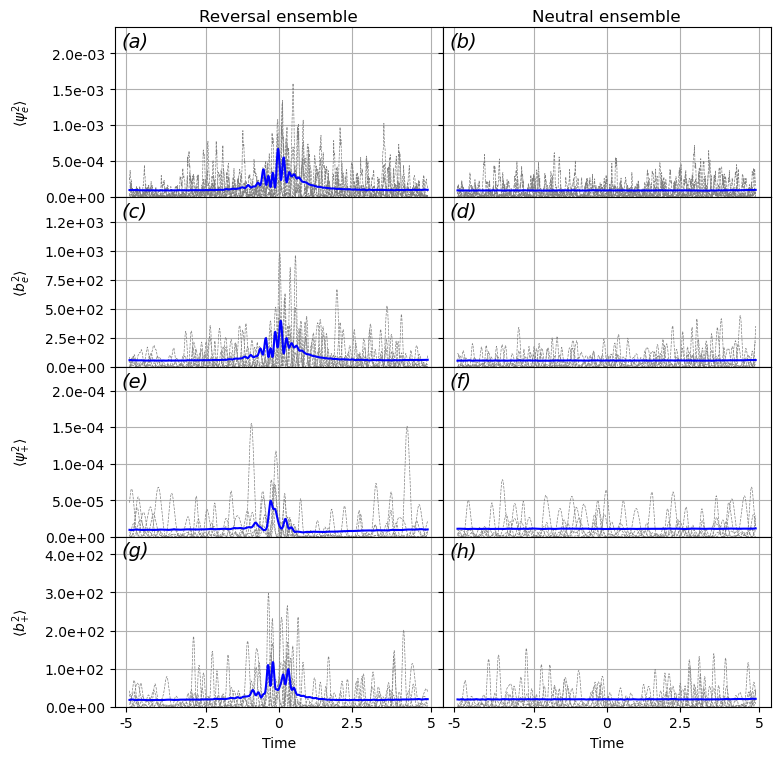

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from string import ascii_lowercase
from matplotlib.ticker import FormatStrFormatter

def jfm_panel_labels(axes, x=-0.10, y=1.02, start=0, **kwargs):
    """
    Add (a), (b), ... to a list/array of axes in JFM style.
    """
    axes = np.ravel(axes)

    defaults = dict(
        fontsize=14,
        fontstyle='italic',
        va='bottom',
        ha='left'
    )
    defaults.update(kwargs)

    for i, ax in enumerate(axes[start:], start=start):
        label = f'({ascii_lowercase[i]})'
        ax.text(x, y, label, transform=ax.transAxes, **defaults)


# ---------- Time array & trimming (match other figures) ----------
time_array = np.arange(-window_size / 10, window_size / 10) * dt * 10

trim = 30
time_avg = time_array[trim:-trim]

# ---------- 4 rows x 2 cols: left = Reversal ensemble, right = Neutral ensemble ----------
fig, axs = plt.subplots(
    4, 2,
    figsize=(8, 8),
    sharex=True,
    gridspec_kw={'hspace': 0, 'wspace': 0}
)

# ---------- Column titles ----------
axs[0, 0].set_title('Reversal ensemble', pad=4)
axs[0, 1].set_title('Neutral ensemble', pad=4)

# ---------- Row 1: KE psi_e → ⟨ψ_e²⟩ ----------
ax = axs[0, 0]
for i in range(5):
    ax.plot(time_avg, df['k_e_psi_e_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_k_e_psi_e_list[trim:-trim],
        label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'$\langle \psi_{e}^{2} \rangle$')
ax.grid()

ax = axs[0, 1]
for i in range(5):
    ax.plot(time_avg, df1['k_e_psi_e_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_k_e_psi_e_list_1[trim:-trim],
        label='Average', linewidth=1.5, color='blue')
ax.set_ylabel('')   # no ylabel on right
# ax.set_yticks([])  # remove y-ticks on right
ax.grid()

# ---------- Row 2: KE b_e → ⟨b_e²⟩ ----------
ax = axs[1, 0]
for i in range(5):
    ax.plot(time_avg, df['k_e_b_e_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_k_e_b_e_list[trim:-trim],
        label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'$\langle b_{e}^{2} \rangle$')
ax.grid()

ax = axs[1, 1]
for i in range(5):
    ax.plot(time_avg, df1['k_e_b_e_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_k_e_b_e_list_1[trim:-trim],
        label='Average', linewidth=1.5, color='blue')
ax.set_ylabel('')
# ax.set_yticks([])  # remove y-ticks on right
ax.grid()

# ---------- Row 3: KE psi_plus → ⟨ψ_+²⟩ ----------
ax = axs[2, 0]
for i in range(5):
    ax.plot(time_avg, df['k_e_psi_plus_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_k_e_psi_plus_list[trim:-trim],
        label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'$\langle \psi_{+}^{2} \rangle$')
ax.grid()

ax = axs[2, 1]
for i in range(5):
    ax.plot(time_avg, df1['k_e_psi_plus_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_k_e_psi_plus_list_1[trim:-trim],
        label='Average', linewidth=1.5, color='blue')
ax.set_ylabel('')
# ax.set_yticks([])  # remove y-ticks on right
ax.grid()

# ---------- Row 4: KE b_plus → ⟨b_+²⟩ ----------
ax = axs[3, 0]
for i in range(5):
    ax.plot(time_avg, df['k_e_b_plus_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_k_e_b_plus_list[trim:-trim],
        label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'$\langle b_{+}^{2} \rangle$')
ax.set_xlabel('Time')
ax.grid()

ax = axs[3, 1]
for i in range(5):
    ax.plot(time_avg, df1['k_e_b_plus_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_k_e_b_plus_list_1[trim:-trim],
        label='Average', linewidth=1.5, color='blue')
ax.set_ylabel('')
ax.set_xlabel('Time')
# ax.set_yticks([])  # remove y-ticks on right
ax.grid()

# ---------- X-axis ticks: match the -5..5 style with nudged positions ----------
positions = [-4.8, -2.3, 0, 2.3, 4.8]
labels    = ['-5', '-2.5', '0', '2.5', '5']

for ax in axs.ravel():
    ax.set_xticks(positions)
    ax.set_xticklabels(labels)

# ---------- Y-axis: symmetric per row, shared L/R ----------
for row in range(4):
    left_ax = axs[row, 0]
    right_ax = axs[row, 1]
    ys = []

    for ax in (left_ax, right_ax):
        for line in ax.get_lines():
            y = line.get_ydata()
            y = y[np.isfinite(y)]
            if y.size:
                ys.append(y)

    if ys:
        ys_all = np.concatenate(ys)
        max_abs = np.max(np.abs(ys_all))
        left_ax.set_ylim(0, max_abs * 1.5)
        right_ax.set_ylim(0, max_abs * 1.5)

# remove y tick labels on the right column
for row in range(4):
    axs[row, 1].tick_params(labelleft=False)

# ---------- Align all left y-labels horizontally ----------
for ax in axs[:, 0]:
    ax.yaxis.set_label_coords(-0.25, 0.5)

# ---------- Panel labels (a)–(h) slightly inside ----------
jfm_panel_labels(axs, x=0.02, y=0.86)

# ---------- Force every y-tick to show in scientific notation ----------
sci_formatter = FormatStrFormatter('%.1e')   # e.g. 1.2e-03; tweak precision if needed

for ax in axs.ravel():
    ax.yaxis.set_major_formatter(sci_formatter)

# ---------- Panels touching, with room for labels ----------
fig.subplots_adjust(
    left=0.16,
    right=0.98,
    top=0.93,
    bottom=0.08,
    wspace=0.0,
    hspace=0.0
)

plt.show()


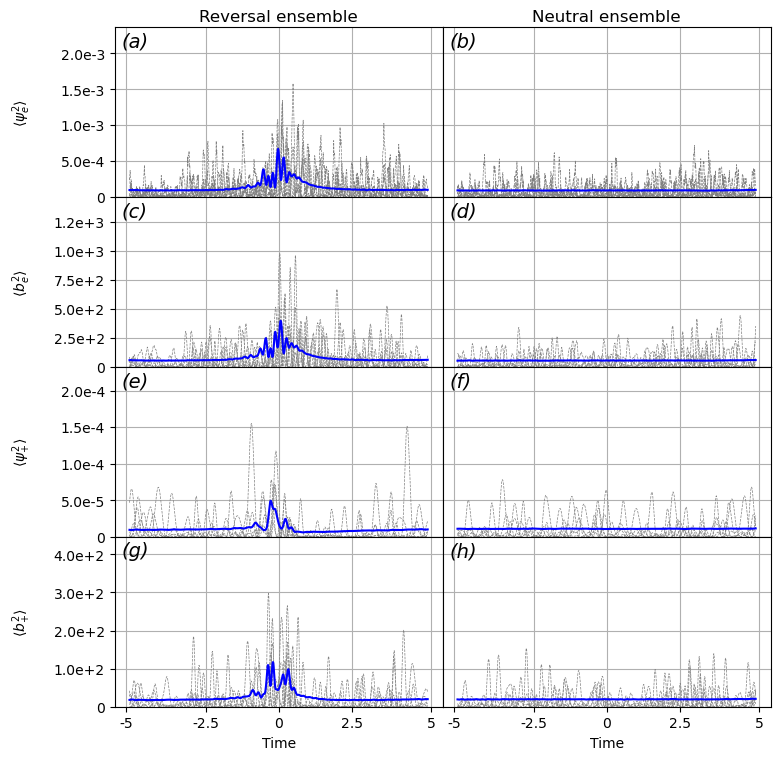

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from string import ascii_lowercase
from matplotlib.ticker import FuncFormatter   # <- changed

def jfm_panel_labels(axes, x=-0.10, y=1.02, start=0, **kwargs):
    """
    Add (a), (b), ... to a list/array of axes in JFM style.
    """
    axes = np.ravel(axes)

    defaults = dict(
        fontsize=14,
        fontstyle='italic',
        va='bottom',
        ha='left'
    )
    defaults.update(kwargs)

    for i, ax in enumerate(axes[start:], start=start):
        label = f'({ascii_lowercase[i]})'
        ax.text(x, y, label, transform=ax.transAxes, **defaults)


# ---------- Time array & trimming (match other figures) ----------
time_array = np.arange(-window_size / 10, window_size / 10) * dt * 10

trim = 30
time_avg = time_array[trim:-trim]

# ---------- 4 rows x 2 cols: left = Reversal ensemble, right = Neutral ensemble ----------
fig, axs = plt.subplots(
    4, 2,
    figsize=(8, 8),
    sharex=True,
    gridspec_kw={'hspace': 0, 'wspace': 0}
)

# ---------- Column titles ----------
axs[0, 0].set_title('Reversal ensemble', pad=4)
axs[0, 1].set_title('Neutral ensemble', pad=4)

# ---------- Row 1: KE psi_e → ⟨ψ_e²⟩ ----------
ax = axs[0, 0]
for i in range(5):
    ax.plot(time_avg, df['k_e_psi_e_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_k_e_psi_e_list[trim:-trim],
        label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'$\langle \psi_{e}^{2} \rangle$')
ax.grid()

ax = axs[0, 1]
for i in range(5):
    ax.plot(time_avg, df1['k_e_psi_e_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_k_e_psi_e_list_1[trim:-trim],
        label='Average', linewidth=1.5, color='blue')
ax.set_ylabel('')   # no ylabel on right
ax.grid()

# ---------- Row 2: KE b_e → ⟨b_e²⟩ ----------
ax = axs[1, 0]
for i in range(5):
    ax.plot(time_avg, df['k_e_b_e_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_k_e_b_e_list[trim:-trim],
        label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'$\langle b_{e}^{2} \rangle$')
ax.grid()

ax = axs[1, 1]
for i in range(5):
    ax.plot(time_avg, df1['k_e_b_e_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_k_e_b_e_list_1[trim:-trim],
        label='Average', linewidth=1.5, color='blue')
ax.set_ylabel('')
ax.grid()

# ---------- Row 3: KE psi_plus → ⟨ψ_+²⟩ ----------
ax = axs[2, 0]
for i in range(5):
    ax.plot(time_avg, df['k_e_psi_plus_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_k_e_psi_plus_list[trim:-trim],
        label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'$\langle \psi_{+}^{2} \rangle$')
ax.grid()

ax = axs[2, 1]
for i in range(5):
    ax.plot(time_avg, df1['k_e_psi_plus_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_k_e_psi_plus_list_1[trim:-trim],
        label='Average', linewidth=1.5, color='blue')
ax.set_ylabel('')
ax.grid()

# ---------- Row 4: KE b_plus → ⟨b_+²⟩ ----------
ax = axs[3, 0]
for i in range(5):
    ax.plot(time_avg, df['k_e_b_plus_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_k_e_b_plus_list[trim:-trim],
        label='Average', linewidth=1.5, color='blue')
ax.set_ylabel(r'$\langle b_{+}^{2} \rangle$')
ax.set_xlabel('Time')
ax.grid()

ax = axs[3, 1]
for i in range(5):
    ax.plot(time_avg, df1['k_e_b_plus_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_k_e_b_plus_list_1[trim:-trim],
        label='Average', linewidth=1.5, color='blue')
ax.set_ylabel('')
ax.set_xlabel('Time')
ax.grid()

# ---------- X-axis ticks: match the -5..5 style with nudged positions ----------
positions = [-4.8, -2.3, 0, 2.3, 4.8]
labels    = ['-5', '-2.5', '0', '2.5', '5']

for ax in axs.ravel():
    ax.set_xticks(positions)
    ax.set_xticklabels(labels)

# ---------- Y-axis: symmetric per row, shared L/R ----------
for row in range(4):
    left_ax = axs[row, 0]
    right_ax = axs[row, 1]
    ys = []

    for ax in (left_ax, right_ax):
        for line in ax.get_lines():
            y = line.get_ydata()
            y = y[np.isfinite(y)]
            if y.size:
                ys.append(y)

    if ys:
        ys_all = np.concatenate(ys)
        max_abs = np.max(np.abs(ys_all))
        left_ax.set_ylim(0, max_abs * 1.5)
        right_ax.set_ylim(0, max_abs * 1.5)

# ---------- Hide y labels & tick marks on the right, keep grid ----------
for row in range(4):
    axs[row, 1].tick_params(
        axis='y',
        which='both',
        labelleft=False,  # no numeric labels
        left=False        # no tick marks
    )

# ---------- Align all left y-labels horizontally ----------
for ax in axs[:, 0]:
    ax.yaxis.set_label_coords(-0.25, 0.5)

# ---------- Panel labels (a)–(h) slightly inside ----------
jfm_panel_labels(axs, x=0.02, y=0.86)

# ---------- Custom y-axis formatter ----------
def custom_sci(x, pos):
    # plain 0, no scientific notation
    if abs(x) < 1e-12:
        return "0"
    # format in scientific notation, then clean exponent
    s = "%.1e" % x          # e.g. '-1.2e+02'
    mant, exp = s.split('e')
    sign = exp[0]           # '+' or '-'
    power = exp[1:].lstrip('0')  # '02' -> '2'
    if power == "":
        power = "0"
    return f"{mant}e{sign}{power}"

formatter = FuncFormatter(custom_sci)

for ax in axs.ravel():
    ax.yaxis.set_major_formatter(formatter)

# ---------- Panels touching, with room for labels ----------
fig.subplots_adjust(
    left=0.16,
    right=0.98,
    top=0.93,
    bottom=0.08,
    wspace=0.0,
    hspace=0.0
)

plt.show()


Heat Flux variables

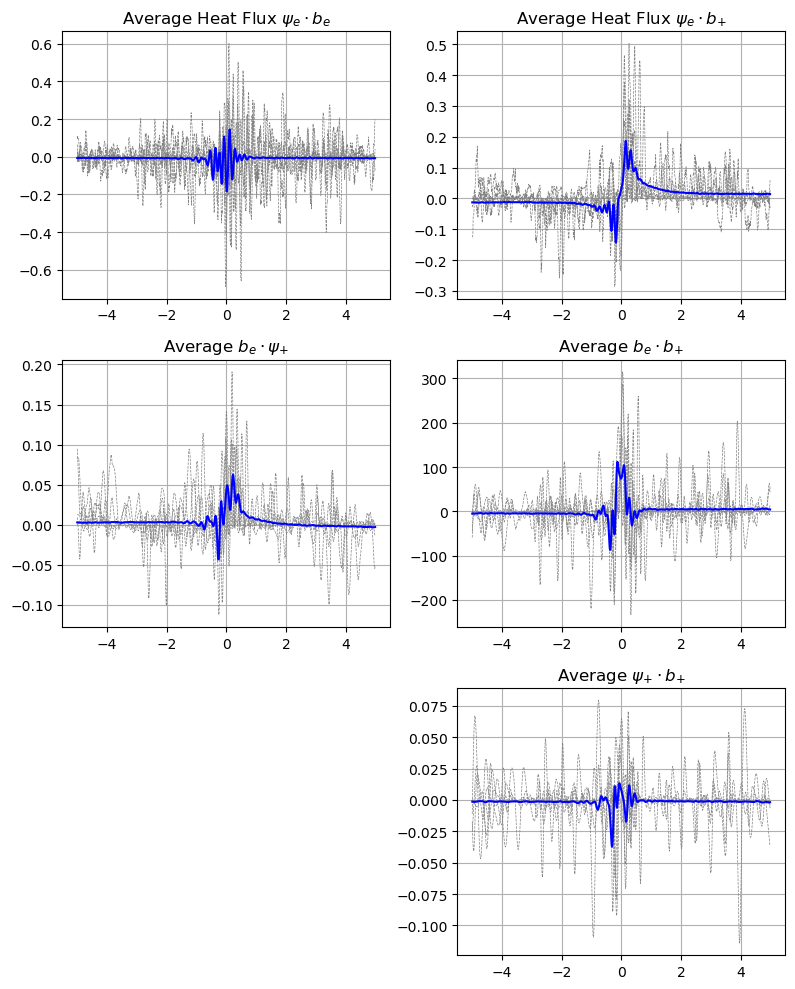

In [23]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(3, 3, figure=fig)  # 3 rows, 3 columns

# Top 4 plots (spread over two rows)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Centered 5th plot in the middle column of bottom row
ax5 = fig.add_subplot(gs[2, 1])  # row 2, column 1 (center)

# Plot each
for i in range(5):
    ax1.plot(time_array, df['heat_flux_psi_e_b_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
ax1.plot(time_array, average_heat_flux_psi_e_b_e_list, linewidth=1.5, color='blue')
ax1.set_title(r'Average Heat Flux $ \psi_{e} \cdot b_{e} $')
ax1.grid()

for i in range(5):
    ax2.plot(time_array, df['heat_flux_psi_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
ax2.plot(time_array, average_heat_flux_psi_e_b_plus_list, linewidth=1.5, color='blue')
ax2.set_title(r'Average Heat Flux $ \psi_{e} \cdot b_{+} $')
ax2.grid()

for i in range(5):
    ax3.plot(time_array, df['b_e_psi_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
ax3.plot(time_array, average_b_e_psi_plus_list, linewidth=1.5, color='blue')
ax3.set_title(r'Average $ b_{e} \cdot \psi_{+} $')
ax3.grid()

for i in range(5):
    ax4.plot(time_array, df['b_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
ax4.plot(time_array, average_b_e_b_plus_list, linewidth=1.5, color='blue')
ax4.set_title(r'Average $ b_{e} \cdot b_{+} $')
ax4.grid()

for i in range(5):
    ax5.plot(time_array, df['psi_plus_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
ax5.plot(time_array, average_psi_plus_b_plus_list, linewidth=1.5, color='blue')
ax5.set_title(r'Average $ \psi_{+} \cdot b_{+} $')
ax5.grid()

plt.tight_layout()
plt.show()


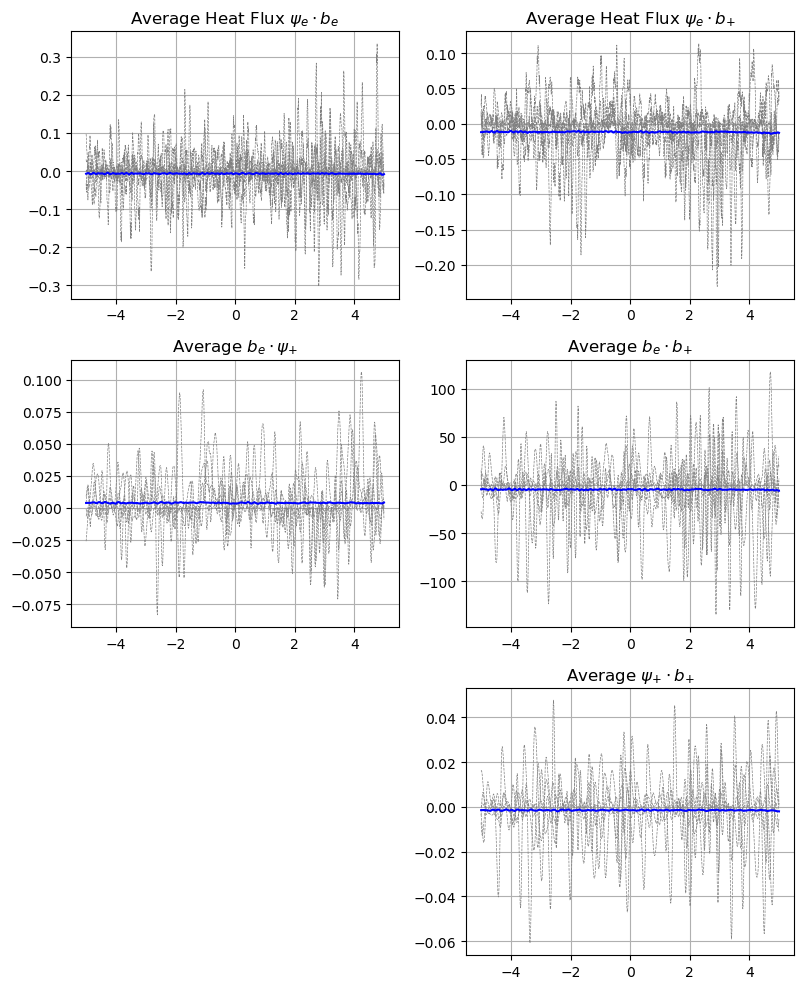

In [24]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(3, 3, figure=fig)  # 3 rows, 3 columns

# Top 4 plots (spread over two rows)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Centered 5th plot in the middle column of bottom row
ax5 = fig.add_subplot(gs[2, 1])  # row 2, column 1 (center)

# Plot each
for i in range(5):
    ax1.plot(time_array, df1['heat_flux_psi_e_b_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
ax1.plot(time_array, average_heat_flux_psi_e_b_e_list_1, linewidth=1.5, color='blue')
ax1.set_title(r'Average Heat Flux $ \psi_{e} \cdot b_{e} $')
ax1.grid()

for i in range(5):
    ax2.plot(time_array, df1['heat_flux_psi_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
ax2.plot(time_array, average_heat_flux_psi_e_b_plus_list_1, linewidth=1.5, color='blue')
ax2.set_title(r'Average Heat Flux $ \psi_{e} \cdot b_{+} $')
ax2.grid()

for i in range(5):
    ax3.plot(time_array, df1['b_e_psi_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
ax3.plot(time_array, average_b_e_psi_plus_list_1, linewidth=1.5, color='blue')
ax3.set_title(r'Average $ b_{e} \cdot \psi_{+} $')
ax3.grid()

for i in range(5):
    ax4.plot(time_array, df1['b_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
ax4.plot(time_array, average_b_e_b_plus_list_1, linewidth=1.5, color='blue')
ax4.set_title(r'Average $ b_{e} \cdot b_{+} $')
ax4.grid()

for i in range(5):
    ax5.plot(time_array, df1['psi_plus_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
ax5.plot(time_array, average_psi_plus_b_plus_list_1, linewidth=1.5, color='blue')
ax5.set_title(r'Average $ \psi_{+} \cdot b_{+} $')
ax5.grid()

plt.tight_layout()
plt.show()


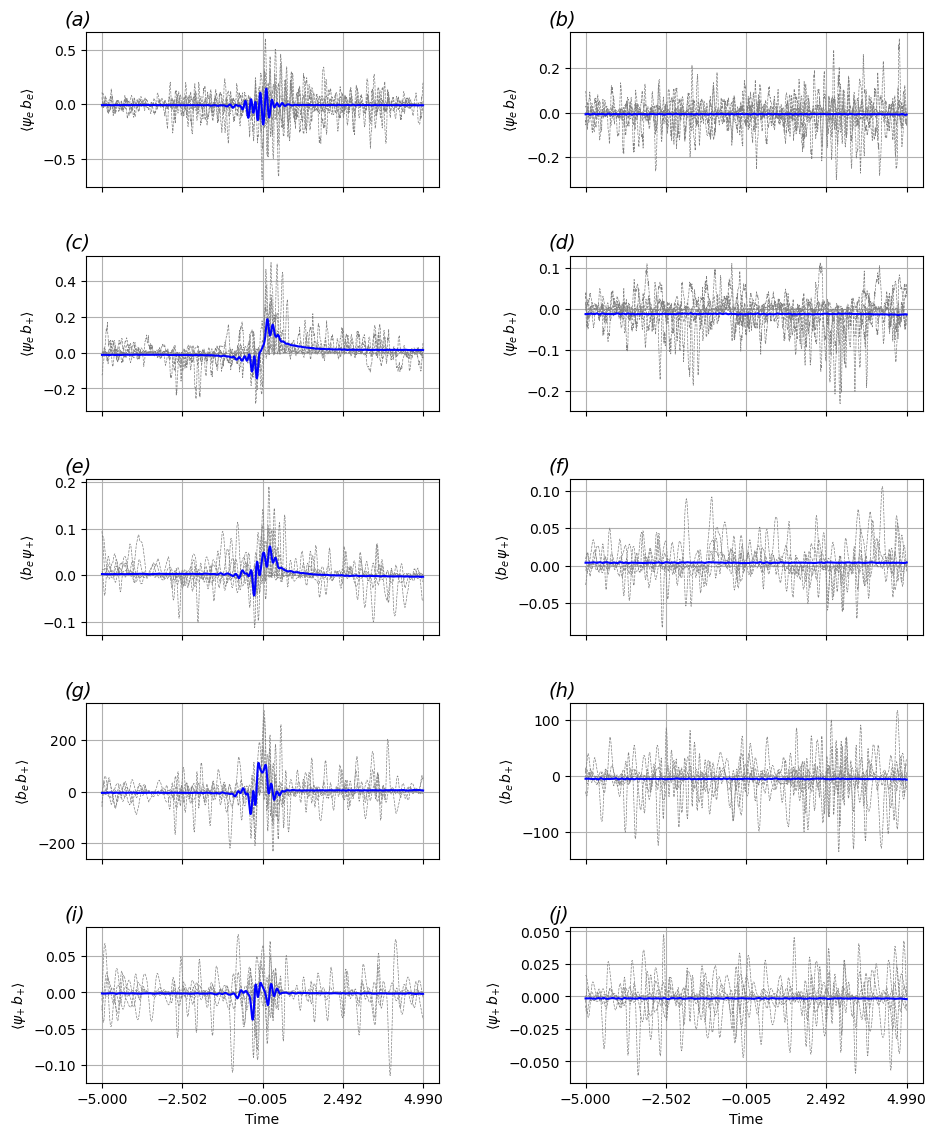

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from string import ascii_lowercase

def jfm_panel_labels(axes, x=-0.08, y=1.02, start=0, **kwargs):
    """
    Add (a), (b), ... to a list/array of axes in JFM style.
    """
    axes = np.ravel(axes)

    defaults = dict(
        fontsize=14,
        fontstyle='italic',
        va='bottom',
        ha='left'
    )
    defaults.update(kwargs)

    for i, ax in enumerate(axes[start:], start=start):
        label = f'({ascii_lowercase[i]})'
        ax.text(x, y, label, transform=ax.transAxes, **defaults)


# Time array (same as before)
time_array = np.arange(-window_size / 10, window_size / 10) * dt * 10

# 5 rows x 2 cols: left = df, right = df1
fig, axs = plt.subplots(5, 2, figsize=(10, 12), sharex=True)

# # Optional column titles
# axs[0, 0].set_title('Case 1')
# axs[0, 1].set_title('Case 2')

# ---------- Row 1: psi_e · b_e ----------
ax = axs[0, 0]
for i in range(5):
    ax.plot(time_array, df['heat_flux_psi_e_b_e_list'][i],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_array, average_heat_flux_psi_e_b_e_list,
        linewidth=1.5, color='blue')
ax.set_ylabel(r'$\langle \psi_{e} \, b_{e} \rangle$')
ax.grid()

ax = axs[0, 1]
for i in range(5):
    ax.plot(time_array, df1['heat_flux_psi_e_b_e_list'][i],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_array, average_heat_flux_psi_e_b_e_list_1,
        linewidth=1.5, color='blue')
ax.set_ylabel(r'$\langle \psi_{e} \, b_{e} \rangle$')
ax.grid()

# ---------- Row 2: psi_e · b_plus ----------
ax = axs[1, 0]
for i in range(5):
    ax.plot(time_array, df['heat_flux_psi_e_b_plus_list'][i],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_array, average_heat_flux_psi_e_b_plus_list,
        linewidth=1.5, color='blue')
ax.set_ylabel(r'$\langle \psi_{e} \, b_{+} \rangle$')
ax.grid()

ax = axs[1, 1]
for i in range(5):
    ax.plot(time_array, df1['heat_flux_psi_e_b_plus_list'][i],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_array, average_heat_flux_psi_e_b_plus_list_1,
        linewidth=1.5, color='blue')
ax.set_ylabel(r'$\langle \psi_{e} \, b_{+} \rangle$')
ax.grid()

# ---------- Row 3: b_e · psi_plus ----------
ax = axs[2, 0]
for i in range(5):
    ax.plot(time_array, df['b_e_psi_plus_list'][i],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_array, average_b_e_psi_plus_list,
        linewidth=1.5, color='blue')
ax.set_ylabel(r'$\langle b_{e} \, \psi_{+} \rangle$')
ax.grid()

ax = axs[2, 1]
for i in range(5):
    ax.plot(time_array, df1['b_e_psi_plus_list'][i],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_array, average_b_e_psi_plus_list_1,
        linewidth=1.5, color='blue')
ax.set_ylabel(r'$\langle b_{e} \, \psi_{+} \rangle$')
ax.grid()

# ---------- Row 4: b_e · b_plus ----------
ax = axs[3, 0]
for i in range(5):
    ax.plot(time_array, df['b_e_b_plus_list'][i],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_array, average_b_e_b_plus_list,
        linewidth=1.5, color='blue')
ax.set_ylabel(r'$\langle b_{e} \, b_{+} \rangle$')
ax.grid()

ax = axs[3, 1]
for i in range(5):
    ax.plot(time_array, df1['b_e_b_plus_list'][i],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_array, average_b_e_b_plus_list_1,
        linewidth=1.5, color='blue')
ax.set_ylabel(r'$\langle b_{e} \, b_{+} \rangle$')
ax.grid()

# ---------- Row 5: psi_plus · b_plus ----------
ax = axs[4, 0]
for i in range(5):
    ax.plot(time_array, df['psi_plus_b_plus_list'][i],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_array, average_psi_plus_b_plus_list,
        linewidth=1.5, color='blue')
ax.set_ylabel(r'$\langle \psi_{+} \, b_{+} \rangle$')
ax.set_xlabel('Time')
ax.grid()

ax = axs[4, 1]
for i in range(5):
    ax.plot(time_array, df1['psi_plus_b_plus_list'][i],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_array, average_psi_plus_b_plus_list_1,
        linewidth=1.5, color='blue')
ax.set_ylabel(r'$\langle \psi_{+} \, b_{+} \rangle$')
ax.set_xlabel('Time')
ax.grid()

# Optional shared x-ticks
for ax in axs.ravel():
    ax.set_xticks(np.linspace(time_array[0], time_array[-1], 5))

# Add (a)–(j)
jfm_panel_labels(axs, x=-0.06, y=1.02)

plt.tight_layout(pad=3)
plt.show()


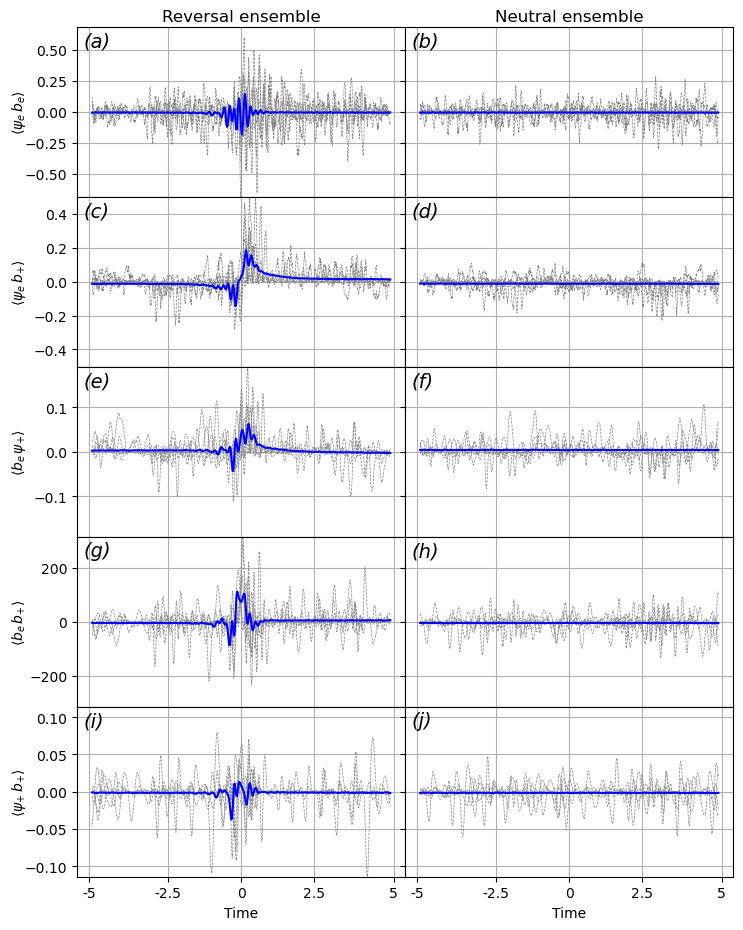

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from string import ascii_lowercase

def jfm_panel_labels(axes, x=-0.08, y=1.02, start=0, **kwargs):
    """
    Add (a), (b), ... to a list/array of axes in JFM style.
    """
    axes = np.ravel(axes)

    defaults = dict(
        fontsize=14,
        fontstyle='italic',
        va='bottom',
        ha='left'
    )
    defaults.update(kwargs)

    for i, ax in enumerate(axes[start:], start=start):
        label = f'({ascii_lowercase[i]})'
        ax.text(x, y, label, transform=ax.transAxes, **defaults)


# ---------- Time array & trimming (same style as first figure) ----------
time_array = np.arange(-window_size / 10, window_size / 10) * dt * 10

trim = 30
time_avg = time_array[trim:-trim]

# ---------- 5 rows x 2 cols: left = Reversal ensemble, right = Neutral ensemble ----------
fig, axs = plt.subplots(
    5, 2,
    figsize=(8, 10),
    sharex=True,
    gridspec_kw={'hspace': 0, 'wspace': 0}
)

# ---------- Column titles ----------
axs[0, 0].set_title('Reversal ensemble', pad=4)
axs[0, 1].set_title('Neutral ensemble', pad=4)

# ---------- Row 1: psi_e · b_e ----------
ax = axs[0, 0]
for i in range(5):
    ax.plot(time_avg, df['heat_flux_psi_e_b_e_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_heat_flux_psi_e_b_e_list[trim:-trim],
        linewidth=1.5, color='blue')
ax.set_ylabel(r'$\langle \psi_{e} \, b_{e} \rangle$')
ax.grid()

ax = axs[0, 1]
for i in range(5):
    ax.plot(time_avg, df1['heat_flux_psi_e_b_e_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_heat_flux_psi_e_b_e_list_1[trim:-trim],
        linewidth=1.5, color='blue')
ax.set_ylabel('')  # no ylabel on the right
ax.grid()

# ---------- Row 2: psi_e · b_plus ----------
ax = axs[1, 0]
for i in range(5):
    ax.plot(time_avg, df['heat_flux_psi_e_b_plus_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_heat_flux_psi_e_b_plus_list[trim:-trim],
        linewidth=1.5, color='blue')
ax.set_ylabel(r'$\langle \psi_{e} \, b_{+} \rangle$')
ax.grid()

ax = axs[1, 1]
for i in range(5):
    ax.plot(time_avg, df1['heat_flux_psi_e_b_plus_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_heat_flux_psi_e_b_plus_list_1[trim:-trim],
        linewidth=1.5, color='blue')
ax.set_ylabel('')
ax.grid()

# ---------- Row 3: b_e · psi_plus ----------
ax = axs[2, 0]
for i in range(5):
    ax.plot(time_avg, df['b_e_psi_plus_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_b_e_psi_plus_list[trim:-trim],
        linewidth=1.5, color='blue')
ax.set_ylabel(r'$\langle b_{e} \, \psi_{+} \rangle$')
ax.grid()

ax = axs[2, 1]
for i in range(5):
    ax.plot(time_avg, df1['b_e_psi_plus_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_b_e_psi_plus_list_1[trim:-trim],
        linewidth=1.5, color='blue')
ax.set_ylabel('')
ax.grid()

# ---------- Row 4: b_e · b_plus ----------
ax = axs[3, 0]
for i in range(5):
    ax.plot(time_avg, df['b_e_b_plus_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_b_e_b_plus_list[trim:-trim],
        linewidth=1.5, color='blue')
ax.set_ylabel(r'$\langle b_{e} \, b_{+} \rangle$')
ax.grid()

ax = axs[3, 1]
for i in range(5):
    ax.plot(time_avg, df1['b_e_b_plus_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_b_e_b_plus_list_1[trim:-trim],
        linewidth=1.5, color='blue')
ax.set_ylabel('')
ax.grid()

# ---------- Row 5: psi_plus · b_plus ----------
ax = axs[4, 0]
for i in range(5):
    ax.plot(time_avg, df['psi_plus_b_plus_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_psi_plus_b_plus_list[trim:-trim],
        linewidth=1.5, color='blue')
ax.set_ylabel(r'$\langle \psi_{+} \, b_{+} \rangle$')
ax.set_xlabel('Time')
ax.grid()

ax = axs[4, 1]
for i in range(5):
    ax.plot(time_avg, df1['psi_plus_b_plus_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_psi_plus_b_plus_list_1[trim:-trim],
        linewidth=1.5, color='blue')
ax.set_ylabel('')
ax.set_xlabel('Time')
ax.grid()

# ---------- X-axis ticks: fake -5 .. 5, like the first plot ----------
positions = [-4.8, -2.3, 0, 2.3, 4.8]
labels    = ['-5', '-2.5', '0', '2.5', '5']

for ax in axs.ravel():
    ax.set_xticks(positions)
    ax.set_xticklabels(labels)

# ---------- Y-axis: symmetric per row, shared L/R ----------
for row in range(5):
    left_ax = axs[row, 0]
    right_ax = axs[row, 1]
    ys = []

    for ax in (left_ax, right_ax):
        for line in ax.get_lines():
            y = line.get_ydata()
            y = y[np.isfinite(y)]
            if y.size:
                ys.append(y)

    if ys:
        ys_all = np.concatenate(ys)
        max_abs = np.max(np.abs(ys_all))
        left_ax.set_ylim(-max_abs, max_abs)
        right_ax.set_ylim(-max_abs, max_abs)

# remove y tick labels on the right column
for row in range(5):
    axs[row, 1].tick_params(labelleft=False)

# ---------- Align all left y-labels horizontally ----------
for ax in axs[:, 0]:
    ax.yaxis.set_label_coords(-0.15, 0.5)

# ---------- Panel labels (a)–(j) slightly inside ----------
jfm_panel_labels(axs, x=0.02, y=0.86)

# ---------- Panels touching, with room for labels ----------
fig.subplots_adjust(
    left=0.16,
    right=0.98,
    top=0.93,
    bottom=0.08,
    wspace=0.0,
    hspace=0.0
)

plt.show()


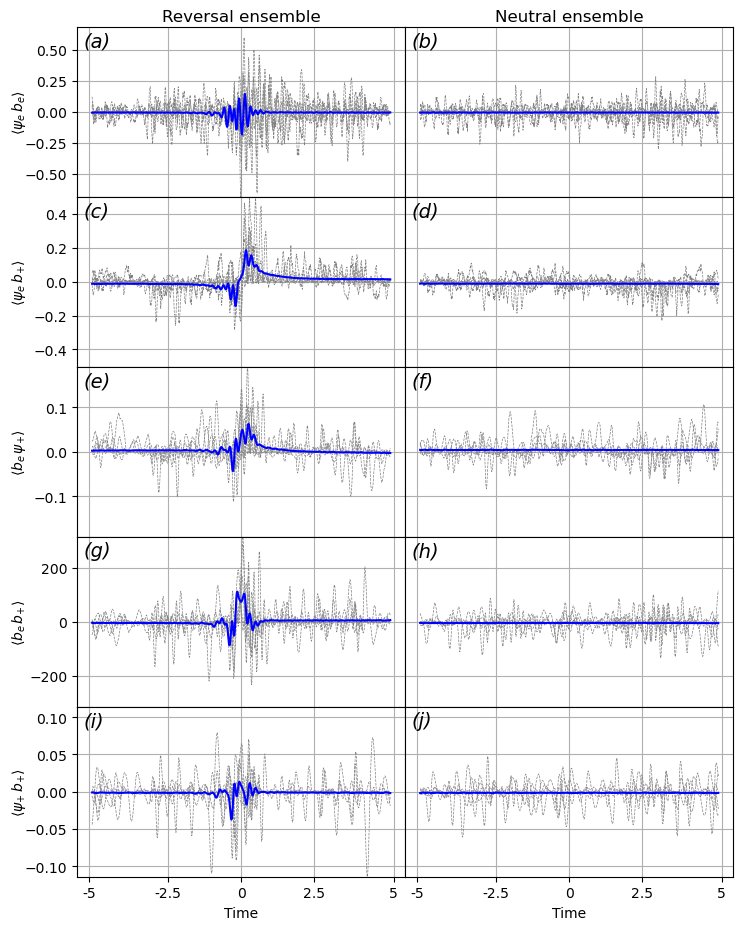

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from string import ascii_lowercase

def jfm_panel_labels(axes, x=-0.08, y=1.02, start=0, **kwargs):
    """
    Add (a), (b), ... to a list/array of axes in JFM style.
    """
    axes = np.ravel(axes)

    defaults = dict(
        fontsize=14,
        fontstyle='italic',
        va='bottom',
        ha='left'
    )
    defaults.update(kwargs)

    for i, ax in enumerate(axes[start:], start=start):
        label = f'({ascii_lowercase[i]})'
        ax.text(x, y, label, transform=ax.transAxes, **defaults)


# ---------- Time array & trimming (same style as first figure) ----------
time_array = np.arange(-window_size / 10, window_size / 10) * dt * 10

trim = 30
time_avg = time_array[trim:-trim]

# ---------- 5 rows x 2 cols: left = Reversal ensemble, right = Neutral ensemble ----------
fig, axs = plt.subplots(
    5, 2,
    figsize=(8, 10),
    sharex=True,
    gridspec_kw={'hspace': 0, 'wspace': 0}
)

# ---------- Column titles ----------
axs[0, 0].set_title('Reversal ensemble', pad=4)
axs[0, 1].set_title('Neutral ensemble', pad=4)

# ---------- Row 1: psi_e · b_e ----------
ax = axs[0, 0]
for i in range(5):
    ax.plot(time_avg, df['heat_flux_psi_e_b_e_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_heat_flux_psi_e_b_e_list[trim:-trim],
        linewidth=1.5, color='blue')
ax.set_ylabel(r'$\langle \psi_{e} \, b_{e} \rangle$')
ax.grid()

ax = axs[0, 1]
for i in range(5):
    ax.plot(time_avg, df1['heat_flux_psi_e_b_e_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_heat_flux_psi_e_b_e_list_1[trim:-trim],
        linewidth=1.5, color='blue')
ax.set_ylabel('')  # no ylabel on the right
ax.grid()

# ---------- Row 2: psi_e · b_plus ----------
ax = axs[1, 0]
for i in range(5):
    ax.plot(time_avg, df['heat_flux_psi_e_b_plus_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_heat_flux_psi_e_b_plus_list[trim:-trim],
        linewidth=1.5, color='blue')
ax.set_ylabel(r'$\langle \psi_{e} \, b_{+} \rangle$')
ax.grid()

ax = axs[1, 1]
for i in range(5):
    ax.plot(time_avg, df1['heat_flux_psi_e_b_plus_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_heat_flux_psi_e_b_plus_list_1[trim:-trim],
        linewidth=1.5, color='blue')
ax.set_ylabel('')
ax.grid()

# ---------- Row 3: b_e · psi_plus ----------
ax = axs[2, 0]
for i in range(5):
    ax.plot(time_avg, df['b_e_psi_plus_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_b_e_psi_plus_list[trim:-trim],
        linewidth=1.5, color='blue')
ax.set_ylabel(r'$\langle b_{e} \, \psi_{+} \rangle$')
ax.grid()

ax = axs[2, 1]
for i in range(5):
    ax.plot(time_avg, df1['b_e_psi_plus_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_b_e_psi_plus_list_1[trim:-trim],
        linewidth=1.5, color='blue')
ax.set_ylabel('')
ax.grid()

# ---------- Row 4: b_e · b_plus ----------
ax = axs[3, 0]
for i in range(5):
    ax.plot(time_avg, df['b_e_b_plus_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_b_e_b_plus_list[trim:-trim],
        linewidth=1.5, color='blue')
ax.set_ylabel(r'$\langle b_{e} \, b_{+} \rangle$')
ax.grid()

ax = axs[3, 1]
for i in range(5):
    ax.plot(time_avg, df1['b_e_b_plus_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_b_e_b_plus_list_1[trim:-trim],
        linewidth=1.5, color='blue')
ax.set_ylabel('')
ax.grid()

# ---------- Row 5: psi_plus · b_plus ----------
ax = axs[4, 0]
for i in range(5):
    ax.plot(time_avg, df['psi_plus_b_plus_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_psi_plus_b_plus_list[trim:-trim],
        linewidth=1.5, color='blue')
ax.set_ylabel(r'$\langle \psi_{+} \, b_{+} \rangle$')
ax.set_xlabel('Time')
ax.grid()

ax = axs[4, 1]
for i in range(5):
    ax.plot(time_avg, df1['psi_plus_b_plus_list'][i][trim:-trim],
            linewidth=0.5, linestyle='--', color='gray')
ax.plot(time_avg, average_psi_plus_b_plus_list_1[trim:-trim],
        linewidth=1.5, color='blue')
ax.set_ylabel('')
ax.set_xlabel('Time')
ax.grid()

# ---------- X-axis ticks: fake -5 .. 5, like the first plot ----------
positions = [-4.8, -2.3, 0, 2.3, 4.8]
labels    = ['-5', '-2.5', '0', '2.5', '5']

for ax in axs.ravel():
    ax.set_xticks(positions)
    ax.set_xticklabels(labels)

# ---------- Y-axis: symmetric per row, shared L/R ----------
for row in range(5):
    left_ax = axs[row, 0]
    right_ax = axs[row, 1]
    ys = []

    for ax in (left_ax, right_ax):
        for line in ax.get_lines():
            y = line.get_ydata()
            y = y[np.isfinite(y)]
            if y.size:
                ys.append(y)

    if ys:
        ys_all = np.concatenate(ys)
        max_abs = np.max(np.abs(ys_all))
        left_ax.set_ylim(-max_abs, max_abs)
        right_ax.set_ylim(-max_abs, max_abs)

# ---------- Hide y labels & tick marks on the right, keep grid ----------
for row in range(5):
    axs[row, 1].tick_params(
        axis='y',
        which='both',
        labelleft=False,  # hide labels
        left=False        # hide tick marks
    )

# ---------- Align all left y-labels horizontally ----------
for ax in axs[:, 0]:
    ax.yaxis.set_label_coords(-0.15, 0.5)

# ---------- Panel labels (a)–(j) slightly inside ----------
jfm_panel_labels(axs, x=0.02, y=0.86)

# ---------- Panels touching, with room for labels ----------
fig.subplots_adjust(
    left=0.16,
    right=0.98,
    top=0.93,
    bottom=0.08,
    wspace=0.0,
    hspace=0.0
)

plt.show()


Noise plots

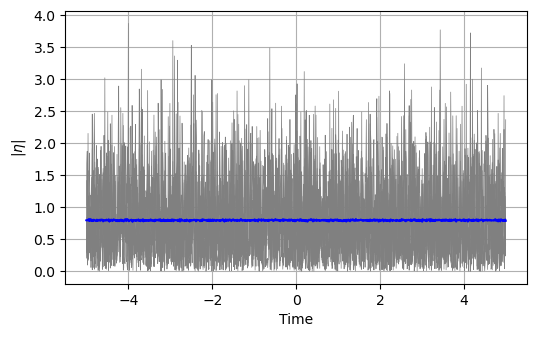

In [28]:
average_eta = [[i for i in sublist] for sublist in average_eta]

time_array = np.arange(-window_size / 10, window_size / 10) * dt * 10

# Create a single subplot
fig, ax = plt.subplots(figsize=(6, 4))

# Plot absolute value of eta_list
for i in range(5):
    ax.plot(time_array, [val[0] for val in np.abs(df['eta_list'][i])], linewidth=0.5, linestyle='-', color='gray')
ax.plot(time_array, [val[0] for val in average_eta], label='Average', linewidth=1.5, color='blue')

# Labels and styling
ax.set_ylabel(r'$|\eta|$')
ax.set_xlabel('Time')
ax.grid()

# Adjust layout
plt.tight_layout(pad=3)
plt.show()

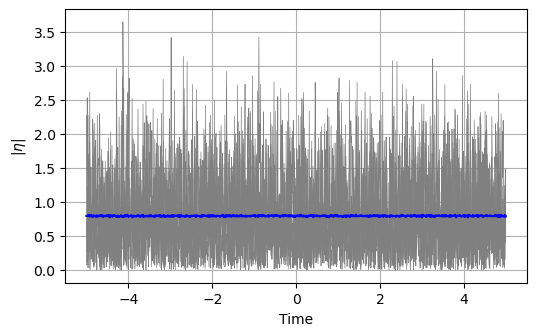

In [27]:
average_eta = [[i for i in sublist] for sublist in average_eta_1]

time_array = np.arange(-window_size / 10, window_size / 10) * dt * 10

# Create a single subplot
fig, ax = plt.subplots(figsize=(6, 4))

# Plot absolute value of eta_list
for i in range(5):
    ax.plot(time_array, [val[0] for val in np.abs(df1['eta_list'][i])], linewidth=0.5, linestyle='-', color='gray')
ax.plot(time_array, [val[0] for val in average_eta], label='Average', linewidth=1.5, color='blue')

# Labels and styling
ax.set_ylabel(r'$|\eta|$')
ax.set_xlabel('Time')
ax.grid()

# Adjust layout
plt.tight_layout(pad=3)
plt.show()

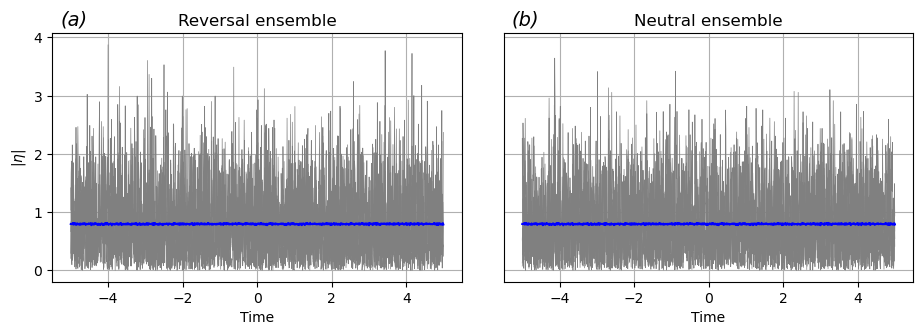

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from string import ascii_lowercase

def jfm_panel_labels(axes, x=-0.08, y=1.02, start=0, **kwargs):
    """
    Add (a), (b), ... to a list/array of axes in JFM style.
    """
    axes = np.ravel(axes)

    defaults = dict(
        fontsize=14,
        fontstyle='italic',
        va='bottom',
        ha='left'
    )
    defaults.update(kwargs)

    for i, ax in enumerate(axes[start:], start=start):
        label = f'({ascii_lowercase[i]})'
        ax.text(x, y, label, transform=ax.transAxes, **defaults)


# ---------- Figure & axes: LEFT/RIGHT layout ----------
fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# ---------- (a) LEFT: Reversal ensemble (df) ----------
ax = axs[0]
for i in range(5):
    ax.plot(
        time_array,
        [val[0] for val in np.abs(df['eta_list'][i])],
        linewidth=0.5,
        linestyle='-',
        color='gray'
    )
ax.plot(
    time_array,
    [val[0] for val in avg_eta_0],
    label='Average',
    linewidth=1.5,
    color='blue'
)
ax.set_title('Reversal ensemble')
ax.set_ylabel(r'$|\eta|$')
ax.set_xlabel('Time')
ax.grid()

# ---------- (b) RIGHT: Neutral ensemble (df1) ----------
ax = axs[1]
for i in range(5):
    ax.plot(
        time_array,
        [val[0] for val in np.abs(df1['eta_list'][i])],
        linewidth=0.5,
        linestyle='-',
        color='gray'
    )
ax.plot(
    time_array,
    [val[0] for val in avg_eta_1],
    label='Average',
    linewidth=1.5,
    color='blue'
)
ax.set_title('Neutral ensemble')
ax.set_xlabel('Time')
ax.grid()

# ---------- Hide y ticks & labels on the right panel, keep grid ----------
axs[1].tick_params(
    axis='y',
    which='both',
    labelleft=False,  # no labels
    left=False        # no tick marks
)

# ---------- Panel labels (a), (b) ----------
jfm_panel_labels(axs, x=0.02, y=1.02)

plt.tight_layout(pad=3)
plt.show()


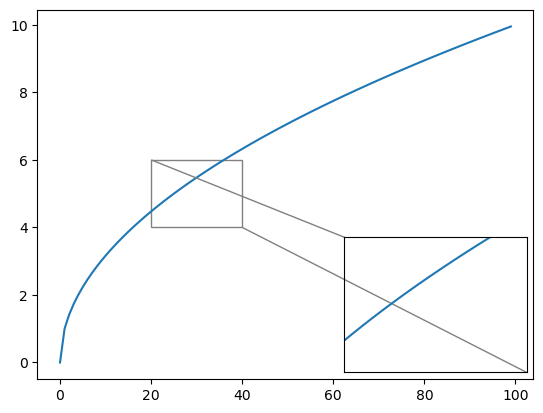

In [49]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

fig, ax = plt.subplots()

x = range(100)
y = [v**0.5 for v in x]
ax.plot(x, y)

# Create zoomed inset: zoom factor controls how much you zoom in
zoom_ax = zoomed_inset_axes(ax, zoom=2, loc="lower right")
zoom_ax.plot(x, y)

# Set zoomed region
zoom_ax.set_xlim(20, 40)
zoom_ax.set_ylim(4, 6)

# Hide inset ticks for aesthetics (optional)
zoom_ax.set_xticks([])
zoom_ax.set_yticks([])

# Draw lines showing which area is zoomed
mark_inset(ax, zoom_ax, loc1=2, loc2=4, fc="none", ec="0.5")

plt.show()
